[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/04_orthogonality_projections_and_qr/first_principles.ipynb)

# Module 04 — Orthogonality, Projections, and QR

## 1. Why This Module Exists

Most linear systems that arise from data have no solution. There are more measurements than
unknowns, the measurements disagree, and $Ax = b$ is inconsistent.

The honest question is then not "which $x$ solves it" but "which $x$ comes closest". That turns
an algebra problem into a geometry problem: find the point of $\operatorname{Col}(A)$ nearest
to $b$.

Orthogonality is the tool that answers it. The nearest point is the one whose error vector is
perpendicular to the subspace, and perpendicularity is an equation you can solve.

The same idea, applied to the columns of $A$ one at a time, produces the **QR factorization**
$A = QR$ — an orthonormal basis for $\operatorname{Col}(A)$ together with the coordinates of the
original columns in it. Every stable least-squares solver, the QR eigenvalue algorithm, and the
orthogonal layers of a neural network are built on it.

## 2. Intuition

Fix a vector $b$ and a subspace $W$. Walk along $W$ looking for the point closest to $b$.

At the closest point the error $b - p$ cannot have any component lying inside $W$: if it did, you
could slide a little further along that component and shorten the error. So the error is
perpendicular to $W$.

That is the whole of the subject in one sentence. **Closest means perpendicular.** Everything
below turns that sentence into formulas, algorithms, and error bounds.

The second idea is that perpendicular coordinate systems are numerically kind. An orthogonal
matrix does not stretch anything, so it cannot amplify a rounding error; a general change of
basis can amplify it by the condition number.

That is why we spend so much effort building orthonormal bases: not because orthonormal bases
are elegant, but because arithmetic performed in them does not lose digits.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single
random generator used everywhere below, and prints the machine epsilon that every residual claim
in this notebook is measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every residual reported later is quoted as a multiple of this number.

The next cell draws the picture described above in the simplest possible case: $W$ is the line
spanned by $a = (3,1)^\top$ and $b = (1,3)^\top$.

The left panel shows the projection $p$, the error $e = b - p$ meeting the line at a right angle,
and one competing point $w \in W$ with its longer error. The right panel plots
$t \mapsto \lVert b - ta \rVert$, whose minimum sits exactly at the $t$ that produces $p$.

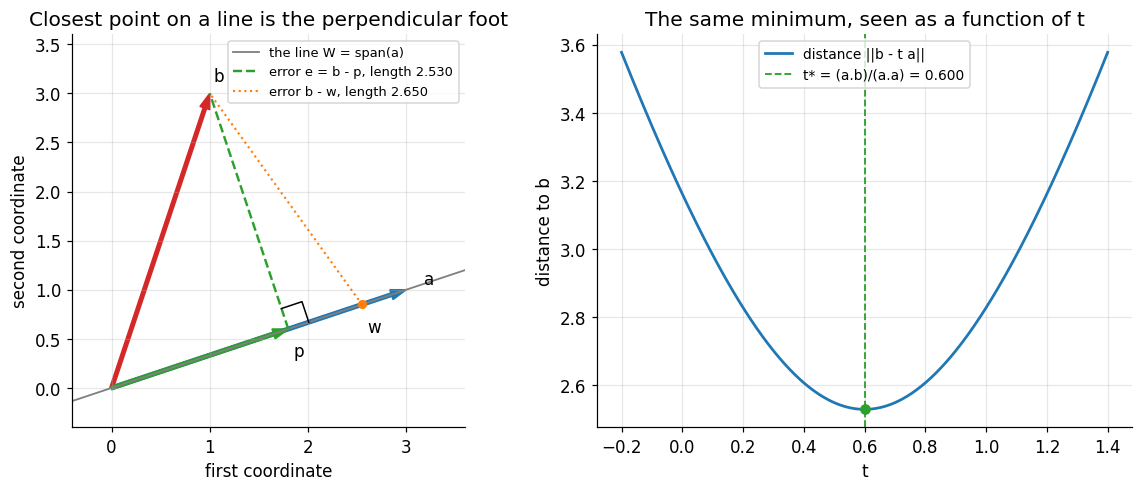

t*                        = 0.6000000000
p = t* a                  = [1.8 0.6]
e = b - p                 = [-0.8  2.4]
a . e                     = 4.441e-16   (zero: e is perpendicular to W)
||e||                     = 2.5298221281
||b - w|| for the competitor w = 0.85 a : 2.6504716561


In [2]:
a = np.array([3.0, 1.0])
b = np.array([1.0, 3.0])

t_star = (a @ b) / (a @ a)
p = t_star * a
e = b - p
w = 0.85 * a                      # a competing point on the line

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.6))

s = np.linspace(-0.15, 1.15, 2)
ax1.plot(s * a[0] * 1.2, s * a[1] * 1.2, lw=1.2, color="0.5", label="the line W = span(a)")
ax1.arrow(0, 0, a[0], a[1], width=0.035, length_includes_head=True, color="tab:blue")
ax1.arrow(0, 0, b[0], b[1], width=0.035, length_includes_head=True, color="tab:red")
ax1.arrow(0, 0, p[0], p[1], width=0.035, length_includes_head=True, color="tab:green")
ax1.plot([p[0], b[0]], [p[1], b[1]], lw=1.6, ls="--", color="tab:green",
         label=f"error e = b - p, length {np.linalg.norm(e):.3f}")
ax1.plot([w[0], b[0]], [w[1], b[1]], lw=1.4, ls=":", color="tab:orange",
         label=f"error b - w, length {np.linalg.norm(b - w):.3f}")
ax1.plot([w[0]], [w[1]], "o", ms=5, color="tab:orange")
n_hat = e / np.linalg.norm(e)
a_hat = a / np.linalg.norm(a)
sq = 0.22
ax1.plot([p[0] + sq * a_hat[0], p[0] + sq * (a_hat[0] + n_hat[0]), p[0] + sq * n_hat[0]],
         [p[1] + sq * a_hat[1], p[1] + sq * (a_hat[1] + n_hat[1]), p[1] + sq * n_hat[1]],
         lw=1.0, color="k")
ax1.annotate("a", a * 1.06)
ax1.annotate("b", b * 1.04)
ax1.annotate("p", p + np.array([0.05, -0.28]))
ax1.annotate("w", w + np.array([0.05, -0.28]))
ax1.set_aspect("equal")
ax1.set_xlim(-0.4, 3.6)
ax1.set_ylim(-0.4, 3.6)
ax1.set_xlabel("first coordinate")
ax1.set_ylabel("second coordinate")
ax1.set_title("Closest point on a line is the perpendicular foot")
ax1.legend(loc="upper right", fontsize=8.5)

ts = np.linspace(-0.2, 1.4, 400)
dist = np.linalg.norm(b[None, :] - ts[:, None] * a[None, :], axis=1)
ax2.plot(ts, dist, lw=1.8, label="distance ||b - t a||")
ax2.axvline(t_star, ls="--", lw=1.2, color="tab:green",
            label=f"t* = (a.b)/(a.a) = {t_star:.3f}")
ax2.plot([t_star], [np.linalg.norm(e)], "o", ms=6, color="tab:green")
ax2.set_xlabel("t")
ax2.set_ylabel("distance to b")
ax2.set_title("The same minimum, seen as a function of t")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"t*                        = {t_star:.10f}")
print(f"p = t* a                  = {p}")
print(f"e = b - p                 = {e}")
print(f"a . e                     = {a @ e:.3e}   (zero: e is perpendicular to W)")
print(f"||e||                     = {np.linalg.norm(e):.10f}")
print(f"||b - w|| for the competitor w = 0.85 a : {np.linalg.norm(b - w):.10f}")
assert abs(a @ e) < 1e-14
assert np.linalg.norm(e) < np.linalg.norm(b - w)

The dashed error meets the line in a right angle and $a \cdot e$ is zero to fourteen digits. The
dotted competitor is longer, and the right panel shows that every other $t$ is worse.

The two panels are the same statement. Perpendicularity is the *derivative-equals-zero* condition
of the distance function, which is why the geometry and the calculus never disagree.

## 3. Definitions

Throughout, vectors are columns, $A^\top$ is the transpose, and $\overline{z}$ is the complex
conjugate. Symbols follow [the notation register](../../docs/notation.md): norms are written
$\lVert x \rVert$, factorizations $A = QR$, and the condition number $\kappa_2$.

### Definition 3.1 — Inner product space, norm

An **inner product** on a vector space $V$ over $\mathbb{R}$ or $\mathbb{C}$ is a map
$\langle \cdot, \cdot \rangle : V \times V \to \mathbb{C}$ that is

- **conjugate symmetric**: $\langle u, v \rangle = \overline{\langle v, u \rangle}$;
- **linear in the first argument**: $\langle \alpha u + \beta w, v \rangle = \alpha \langle u, v \rangle + \beta \langle w, v \rangle$;
- **positive definite**: $\langle v, v \rangle \ge 0$, with equality only for $v = 0$.

The induced **norm** is $\lVert v \rVert = \sqrt{\langle v, v \rangle}$.

Positive definiteness is the axiom that makes the norm a norm; drop it and Cauchy-Schwarz
survives but "distance zero implies equal" does not.

On $\mathbb{R}^n$ the default is $\langle u, v \rangle = u^\top v$, so $\lVert v \rVert = \lVert v \rVert_2$.

### Definition 3.2 — Orthogonality, orthonormal sets, orthogonal complement

Vectors $u, v$ are **orthogonal**, written $u \perp v$, when $\langle u, v \rangle = 0$.

A set $\{e_1, \dots, e_k\}$ is **orthonormal** when $\langle e_i, e_j \rangle = \delta_{ij}$: pairwise
orthogonal and each of unit length.

For a subspace $W \subseteq V$ the **orthogonal complement** is

$$
W^{\perp} = \{ v \in V : \langle v, w \rangle = 0 \ \text{ for every } w \in W \} .
$$

$W^{\perp}$ is itself a subspace, and $W \cap W^{\perp} = \{0\}$ because $x$ in both forces
$\langle x, x \rangle = 0$.

### Definition 3.3 — Gram matrix

For $v_1, \dots, v_n \in V$ the **Gram matrix** is $G_{ij} = \langle v_j, v_i \rangle$. When
$V = \mathbb{R}^m$ and $A = [\, v_1 \ \cdots \ v_n \,]$ this is

$$
G = A^\top A .
$$

The Gram matrix records every length and every angle among the $v_i$ and nothing else, which is
exactly the information a kernel method has access to.

### Definition 3.4 — Orthogonal projection onto a subspace

Let $W \subseteq V$ be a finite-dimensional subspace. A map $P : V \to V$ is the **orthogonal
projection onto $W$** when for every $v$

$$
Pv \in W \qquad \text{and} \qquad v - Pv \in W^{\perp} .
$$

Theorem 4.4 shows that exactly one such $Pv$ exists, so the definition is not vacuous and $P$ is
well defined. We write $P_W$ when the subspace needs naming.

A matrix $P$ with $P^2 = P$ but $P^\top \neq P$ is an **oblique projection**: it still maps onto
a subspace and fixes it, but the error it leaves is not perpendicular.

### Definition 3.5 — Orthogonal matrix, reflector, rotation

$Q \in \mathbb{R}^{m \times n}$ has **orthonormal columns** when $Q^\top Q = I_n$. If in addition
$m = n$ then $Q$ is an **orthogonal matrix** and also $QQ^\top = I$.

For $v \neq 0$ the **Householder reflector** is

$$
H = I - 2 \frac{v v^\top}{v^\top v},
$$

the reflection of $\mathbb{R}^m$ across the hyperplane $v^{\perp}$.

The **Givens rotation** $G(i,j,\theta)$ is the identity except in rows and columns $i, j$, where
it carries $\begin{pmatrix} c & s \\ -s & c \end{pmatrix}$ with $c = \cos\theta$,
$s = \sin\theta$. It rotates the $(i,j)$ coordinate plane and leaves everything else fixed.

### Definition 3.6 — QR factorization

Let $A \in \mathbb{R}^{m \times n}$ with $m \ge n$.

- The **full QR factorization** is $A = QR$ with $Q \in \mathbb{R}^{m \times m}$ orthogonal and
  $R \in \mathbb{R}^{m \times n}$ upper triangular.
- The **thin QR factorization** is $A = \hat{Q}\hat{R}$ with $\hat{Q} \in \mathbb{R}^{m \times n}$
  having orthonormal columns and $\hat{R} \in \mathbb{R}^{n \times n}$ upper triangular.

The thin factorization is the first $n$ columns of $Q$ and the first $n$ rows of $R$; the discarded
columns of $Q$ span $\operatorname{Col}(A)^{\perp}$ when $A$ has full column rank.

### Definition 3.7 — Operator norm, pseudoinverse, condition number

For $A \in \mathbb{R}^{m \times n}$ put

$$
\lVert A \rVert_2 = \max_{\lVert x \rVert = 1} \lVert Ax \rVert,
\qquad
\sigma_{\min}(A) = \min_{\lVert x \rVert = 1} \lVert Ax \rVert .
$$

If $A$ has full column rank then $\sigma_{\min}(A) \gt 0$, the **pseudoinverse**
$A^{+} = (A^\top A)^{-1} A^\top$ exists, and the **2-norm condition number** is

$$
\kappa_2(A) = \lVert A \rVert_2 \, \lVert A^{+} \rVert_2 = \frac{\lVert A \rVert_2}{\sigma_{\min}(A)} .
$$

The second equality is proved as Step 1 of Proof 5.10. For rectangular $A$ there is no $A^{-1}$,
so the pseudoinverse is not a convenience here — it is the only available definition.

### Definition 3.8 — Volume of a parallelotope

For linearly independent $a_1, \dots, a_n \in \mathbb{R}^m$ define the volume of the parallelotope
they span **recursively**:

$$
\operatorname{Vol}(a_1) = \lVert a_1 \rVert,
\qquad
\operatorname{Vol}(a_1, \dots, a_k) = \operatorname{Vol}(a_1, \dots, a_{k-1}) \cdot d_k,
$$

where $d_k = \operatorname{dist}\bigl(a_k, \operatorname{span}(a_1, \dots, a_{k-1})\bigr)$ is the
distance from $a_k$ to the span of its predecessors.

This is the school rule *base times height*, iterated, with "height" meaning the perpendicular
height — which is why the volume is a projection question and belongs in this module.

### Definition 3.9 — Unit roundoff and backward stability

IEEE double arithmetic satisfies $\operatorname{fl}(x \circ y) = (x \circ y)(1 + \delta)$ with
$\lvert \delta \rvert \le u$, where the **unit roundoff** is $u = 2^{-53} \approx 1.11 \times 10^{-16}$.

An algorithm for computing $F(A)$ is **backward stable** when the computed answer is the exact
answer for a nearby input:

$$
\widehat{F}(A) = F(A + \Delta A), \qquad \lVert \Delta A \rVert_2 = O(u) \lVert A \rVert_2 .
$$

Backward stability is a statement about the algorithm; how much the answer then moves is a
statement about the problem, and that is what $\kappa_2$ measures.

## 4. Main Results

Theorems 4.1 to 4.5 are the geometry: an inequality, a completeness criterion, the construction
of orthonormal bases, the splitting $V = W \oplus W^{\perp}$, and the fact that projection means
nearest.

Theorems 4.6 to 4.8 are the algebra and the algorithms: the matrix form of a projection, the
normal equations, and the factorization the module is named after.

Theorems 4.9 to 4.11 and Proposition 4.12 are what makes any of it usable in floating point:
volume, orthogonal invariance, the conditioning of the normal equations, and one case where the
failure can be predicted exactly.

### Theorem 4.1 — Cauchy-Schwarz inequality, with the equality case

For all $u, v$ in an inner product space,

$$
\lvert \langle u, v \rangle \rvert \le \lVert u \rVert \, \lVert v \rVert ,
$$

with equality if and only if $u$ and $v$ are linearly dependent.

**Hypotheses.** Only the three inner-product axioms. Positive definiteness is the one that does
the work: it is what makes $\lVert u - cv \rVert^2 \ge 0$ informative, and it is what turns the
equality case into an identity rather than a degeneracy.

Proved as Proof 5.1.

### Theorem 4.2 — Bessel's inequality and Parseval's identity

Let $\{e_1, \dots, e_k\}$ be an orthonormal set in $V$ and let $v \in V$. Then

$$
\sum_{i=1}^{k} \lvert \langle v, e_i \rangle \rvert^2 \le \lVert v \rVert^2 ,
$$

with equality **for that particular $v$** if and only if $v \in \operatorname{span}(e_1, \dots, e_k)$.

Consequently, equality holds **for every $v \in V$** if and only if $\{e_1, \dots, e_k\}$ is an
orthonormal basis of $V$; that statement is **Parseval's identity**.

**Hypotheses.** Orthonormality of the $e_i$ is what collapses the double sum in
$\lVert p \rVert^2$ to a single sum. The universal quantifier "for every $v$" is load-bearing:
in $\mathbb{R}^2$ the set $\{e_1\}$ is not a basis, yet equality holds at $v = e_1$. Section 7.4
runs that counterexample.

Proved as Proof 5.2.

### Theorem 4.3 — Gram-Schmidt

Let $a_1, \dots, a_n$ be linearly independent in an inner product space. There exist orthonormal
$q_1, \dots, q_n$ and scalars $r_{jk}$ with $r_{kk} \gt 0$ such that

$$
a_k = \sum_{j=1}^{k} r_{jk} q_j
\qquad \text{and} \qquad
\operatorname{span}(a_1, \dots, a_k) = \operatorname{span}(q_1, \dots, q_k)
$$

for every $k$. In particular every finite-dimensional subspace has an orthonormal basis.

**Hypotheses.** Linear independence, and only that. It is needed at every step to guarantee
$v_k \neq 0$, hence $r_{kk} \gt 0$; without it the algorithm divides by zero at the first
dependent column.

Proved as Proof 5.3.

### Theorem 4.4 — Orthogonal decomposition

Let $W$ be a finite-dimensional subspace of an inner product space $V$. Every $v \in V$ has one
and only one decomposition

$$
v = w + z, \qquad w \in W, \quad z \in W^{\perp} .
$$

Equivalently $V = W \oplus W^{\perp}$.

**Hypotheses.** $W$ finite-dimensional. That is what lets Theorem 4.3 produce an orthonormal
basis of $W$ and hence build $w$ explicitly; for an infinite-dimensional $W$ the statement needs
$W$ closed and $V$ complete, and the construction is a limit rather than a finite sum.

**Interpretation.** *Meaning:* a subspace and its complement carve the space into two
independent halves. *Consequence:* every vector splits once, into a part $W$ can explain and a
part it cannot, and the split is forced, not chosen.

Proved as Proof 5.4.

### Theorem 4.5 — Best approximation

Let $W \subseteq V$ be a finite-dimensional subspace, $v \in V$, and $p \in W$. Then

$$
p = P_W v
\quad \Longleftrightarrow \quad
v - p \perp W
\quad \Longleftrightarrow \quad
\lVert v - p \rVert \lt \lVert v - w \rVert \ \text{ for every } w \in W, \ w \neq p .
$$

In particular the minimizer of $\lVert v - w \rVert$ over $w \in W$ exists and is unique.

**Hypotheses.** $W$ a subspace, so that $p - w$ stays inside $W$ and Pythagoras applies. For a
merely convex set the perpendicularity equation weakens to the variational inequality
$\langle v - p, \, z - p \rangle \le 0$ for all $z$ in the set.

Proved as Proof 5.5.

### Theorem 4.6 — Projection matrices

Let $P \in \mathbb{R}^{m \times m}$. Then $P$ is the orthogonal projection onto some subspace if
and only if

$$
P^2 = P \qquad \text{and} \qquad P^\top = P,
$$

and in that case the subspace is $\operatorname{Col}(P)$.

If $A \in \mathbb{R}^{m \times n}$ has full column rank, then $A^\top A$ is invertible and the
orthogonal projection onto $\operatorname{Col}(A)$ is

$$
P = A (A^\top A)^{-1} A^\top .
$$

If $A = \hat{Q}\hat{R}$ is a thin QR factorization, the same projector is $P = \hat{Q}\hat{Q}^\top$.

**Hypotheses.** Idempotence alone gives an oblique projection, which does *not* minimize distance;
Section 7.4 exhibits one whose error is $41$ percent larger than the true minimum. Full column
rank is needed for $A^\top A$ to be invertible: without it the displayed formula does not exist,
though the projector still does.

Proved as Proof 5.6.

### Theorem 4.7 — Least squares and the normal equations

Let $A \in \mathbb{R}^{m \times n}$ and $b \in \mathbb{R}^m$. Then $\hat{x}$ minimizes
$\lVert Ax - b \rVert$ if and only if

$$
A^\top A \hat{x} = A^\top b ,
$$

and the residual $e = b - A\hat{x}$ satisfies $A^\top e = 0$. The minimizer is unique if and only
if $A$ has full column rank, in which case

$$
\hat{x} = (A^\top A)^{-1} A^\top b = A^{+} b .
$$

**Hypotheses.** None for existence: the normal equations are always consistent, because
$A^\top b \in \operatorname{Col}(A^\top A)$. Full column rank is needed only for uniqueness.

**Interpretation.** *Meaning:* fitting by least squares is projecting $b$ onto the column space.
*Consequence:* the residual carries no information the model could have used, which is exactly
what "no systematic error left" means in a regression diagnostic.

Proved as Proof 5.7.

### Theorem 4.8 — QR factorization: existence and uniqueness

Let $A \in \mathbb{R}^{m \times n}$ with $m \ge n$.

**Existence.** A full QR factorization $A = QR$ exists, with $Q$ orthogonal and $R$ upper
triangular. No rank assumption is needed.

**Uniqueness.** If $A$ has full column rank, there is exactly one thin factorization
$A = \hat{Q}\hat{R}$ with $\hat{Q}^\top \hat{Q} = I_n$ and $\hat{R}$ upper triangular with
$r_{ii} \gt 0$ for every $i$.

**Hypotheses.** Existence needs nothing beyond $m \ge n$, because the Householder construction
never divides by a quantity that can vanish. Uniqueness needs both full column rank and the sign
normalization $r_{ii} \gt 0$: flipping the sign of any column of $\hat{Q}$ and the matching row
of $\hat{R}$ gives another valid factorization, and Example 6.4 produces one with $r_{11} \lt 0$
by a legitimate algorithm. Section 7.4 shows uniqueness failing outright when the rank drops.

Proved as Proof 5.8.

### Theorem 4.9 — Gram-Schmidt computes volume

Let $a_1, \dots, a_n \in \mathbb{R}^m$ be linearly independent with thin QR factorization
$A = \hat{Q}\hat{R}$, $r_{ii} \gt 0$. Then, with $\operatorname{Vol}$ as in Definition 3.8,

$$
\operatorname{Vol}(a_1, \dots, a_n) = \prod_{i=1}^{n} r_{ii} .
$$

**Hypotheses.** Linear independence. If the $a_i$ are dependent, some $a_k$ lies in the span of
its predecessors, so $d_k = 0$ and both sides vanish once $\operatorname{Vol}$ is extended by the
same recursion.

**A remark on the determinant form.** The familiar identity
$\det(A^\top A) = \operatorname{Vol}(a_1, \dots, a_n)^2$ follows from $A^\top A = \hat{R}^\top \hat{R}$
*once determinant multiplicativity is available*. This module does not assume it, so the theorem
is stated and proved in the product-of-pivots form, which needs nothing but Theorem 4.3. The
determinant version is checked numerically in Section 6 and cited to Strang,
*Introduction to Linear Algebra*, 5th ed., section 5.1.

Proved as Proof 5.9.

### Theorem 4.10 — Orthogonal invariance and the conditioning of the normal equations

Let $Q$ have orthonormal columns and let $A$ have full column rank. Then

$$
\lVert Qx \rVert = \lVert x \rVert,
\qquad
\lVert QA \rVert_2 = \lVert A \rVert_2,
\qquad
\lVert QA \rVert_F = \lVert A \rVert_F,
\qquad
\kappa_2(QA) = \kappa_2(A),
$$

and

$$
\kappa_2(A^\top A) = \kappa_2(A)^2 .
$$

**Hypotheses.** $Q^\top Q = I$ for the invariance statements, and full column rank for
$\kappa_2$ to be finite. Nothing here needs $Q$ square.

**Interpretation.** *Meaning:* multiplying by an orthogonal matrix changes no length, no norm and
no condition number, while forming $A^\top A$ squares the condition number. *Consequence:* an
algorithm built from orthogonal transformations cannot manufacture ill-conditioning, and one
built from the normal equations always does — it throws away half of the available digits before
the solve begins.

Proved as Proof 5.10.

### Theorem 4.11 (cited, not proved here) — Stability of QR algorithms

Let $A \in \mathbb{R}^{m \times n}$, $m \ge n$, be factored in IEEE arithmetic with unit roundoff
$u$, and write $\tilde{\gamma}_k = cku/(1 - cku)$ for a modest constant $c$.

**Householder QR is backward stable.** The computed $\hat{R}$ satisfies

$$
A + \Delta A = \tilde{Q} \hat{R}, \qquad \lVert \Delta a_j \rVert \le \tilde{\gamma}_{mn} \lVert a_j \rVert ,
$$

for an exactly orthogonal $\tilde{Q}$, and the assembled $\hat{Q}$ obeys
$\lVert \hat{Q}^\top \hat{Q} - I \rVert_2 = O(u)$ independently of $\kappa_2(A)$.

**Gram-Schmidt loses orthogonality in proportion to the conditioning.**

$$
\lVert \hat{Q}^\top \hat{Q} - I \rVert_2 = O\bigl(u \, \kappa_2(A)\bigr) \ \text{ for MGS},
\qquad
O\bigl(u \, \kappa_2(A)^2\bigr) \ \text{ for CGS}.
$$

**Why it is quoted rather than proved.** Each bound is a full rounding-error analysis of an
$O(mn^2)$-operation algorithm; that analysis is a chapter, not a paragraph, and it belongs to a
numerical-analysis course. What this module *does* prove in full is the conditioning half of the
story — Theorem 4.10 — and one case where the arithmetic failure can be predicted exactly,
Proposition 4.12.

Sources: Higham, *Accuracy and Stability of Numerical Algorithms*, 2nd ed., section 19.3
(Theorem 19.4) for Householder; Bjorck, *BIT* **7** (1967), 1-21, and Higham section 19.8 for MGS;
Giraud, Langou, Rozloznik and van den Eshof, *Numerische Mathematik* **101** (2005), 87-100, for
the CGS bound. Section 7.3 measures all three exponents.

### Proposition 4.12 — The Lauchli matrix breaks the normal equations exactly

Fix $\varepsilon \gt 0$ and let

$$
A_\varepsilon = \begin{pmatrix} 1 & 1 & 1 \\ \varepsilon & 0 & 0 \\ 0 & \varepsilon & 0 \\ 0 & 0 & \varepsilon \end{pmatrix},
\qquad
A_\varepsilon^\top A_\varepsilon = \varepsilon^2 I_3 + \mathbf{1}\mathbf{1}^\top .
$$

In exact arithmetic $A_\varepsilon$ has full column rank for every $\varepsilon \gt 0$, and

$$
\kappa_2(A_\varepsilon) = \frac{\sqrt{3 + \varepsilon^2}}{\varepsilon},
\qquad
\kappa_2(A_\varepsilon^\top A_\varepsilon) = \frac{3 + \varepsilon^2}{\varepsilon^2} .
$$

In IEEE double arithmetic, if $\varepsilon^2 \lt u$ then every diagonal entry rounds as
$\operatorname{fl}(1 + \varepsilon^2) = 1$, so the computed Gram matrix is exactly
$\mathbf{1}\mathbf{1}^\top$, which has rank $1$. The normal equations then cannot be formed at all,
while Householder QR is unaffected.

**Hypotheses.** Only $\varepsilon^2 \lt u$ and round-to-nearest. No probabilistic model of
rounding is involved: the failure is deterministic.

Proved as Proof 5.11.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, Cauchy-Schwarz)

If $v = 0$ both sides are zero and $u, v$ are dependent, so assume $v \neq 0$.

*Step 1 — split $u$ along $v$.* Put

$$
c = \frac{\langle u, v \rangle}{\lVert v \rVert^2}, \qquad p = c v, \qquad w = u - p .
$$

*Step 2 — the remainder is orthogonal to $v$.* Linearity in the first argument gives

$$
\langle w, v \rangle = \langle u, v \rangle - c \lVert v \rVert^2 = 0 ,
$$

hence also $\langle w, p \rangle = \overline{c} \langle w, v \rangle = 0$.

*Step 3 — Pythagoras.* Expanding $\lVert p + w \rVert^2$ and using $\langle w, p \rangle = 0$,

$$
\lVert u \rVert^2 = \lVert p \rVert^2 + \lVert w \rVert^2 \ \ge \ \lVert p \rVert^2
= \lvert c \rvert^2 \lVert v \rVert^2 = \frac{\lvert \langle u, v \rangle \rvert^2}{\lVert v \rVert^2} .
$$

Multiplying by $\lVert v \rVert^2$ and taking square roots gives the inequality.

*Step 4 — the equality case.* Equality forces $\lVert w \rVert^2 = 0$, and positive definiteness
turns that into $w = 0$, that is $u = cv$. Conversely $u = cv$ makes both sides
$\lvert c \rvert \lVert v \rVert^2$. $\blacksquare$

$$
\boxed{\lvert \langle u, v \rangle \rvert \le \lVert u \rVert \, \lVert v \rVert, \quad \text{equality iff } u, v \text{ dependent}}
$$

**Interpretation.** *Meaning:* the inner product of two vectors never exceeds the product of their
lengths, so $\langle u,v \rangle / (\lVert u \rVert \lVert v \rVert)$ always lies in $[-1,1]$ and can be
called a cosine. *Consequence:* cosine similarity is well defined, and the triangle inequality
follows in three lines.

### Proof 5.2 (of Theorem 4.2, Bessel and Parseval)

*Step 1 — build the projection onto the span.* Put

$$
p = \sum_{i=1}^{k} \langle v, e_i \rangle e_i, \qquad w = v - p .
$$

*Step 2 — the remainder is orthogonal to every $e_j$.* Orthonormality gives

$$
\langle w, e_j \rangle = \langle v, e_j \rangle - \sum_{i=1}^{k} \langle v, e_i \rangle \langle e_i, e_j \rangle
= \langle v, e_j \rangle - \langle v, e_j \rangle = 0 ,
$$

so $w \perp \operatorname{span}(e_1, \dots, e_k)$ and in particular $w \perp p$.

*Step 3 — evaluate the projection's length.* Expanding the double sum and collapsing it with
$\langle e_i, e_j \rangle = \delta_{ij}$,

$$
\lVert p \rVert^2 = \sum_{i=1}^{k} \sum_{j=1}^{k} \langle v, e_i \rangle \overline{\langle v, e_j \rangle} \langle e_i, e_j \rangle
= \sum_{i=1}^{k} \lvert \langle v, e_i \rangle \rvert^2 .
$$

*Step 4 — Pythagoras and the equality case.* From $\lVert v \rVert^2 = \lVert p \rVert^2 + \lVert w \rVert^2$,

$$
\sum_{i=1}^{k} \lvert \langle v, e_i \rangle \rvert^2 \le \lVert v \rVert^2 ,
$$

with equality exactly when $w = 0$, that is exactly when $v = p \in \operatorname{span}(e_1, \dots, e_k)$.

*Step 5 — quantify over $v$.* Equality holds for **every** $v \in V$ if and only if every $v$ lies
in $\operatorname{span}(e_1, \dots, e_k)$, that is if and only if the orthonormal set spans $V$ and
is therefore an orthonormal basis. $\blacksquare$

$$
\boxed{\sum_{i=1}^{k} \lvert \langle v, e_i \rangle \rvert^2 \le \lVert v \rVert^2, \quad \text{equality for all } v \iff \{e_i\} \text{ is a basis}}
$$

**Interpretation.** *Meaning:* the energy captured by a partial set of orthonormal directions
never exceeds the total. *Consequence:* Step 5 is where the audit's quantifier lives — a single
$v$ can achieve equality against a set that is nowhere near a basis, so "if and only if" is false
without "for every $v$".

### Proof 5.3 (of Theorem 4.3, Gram-Schmidt)

By induction on $k$.

*Base case.* Independence forces $a_1 \neq 0$, so $r_{11} = \lVert a_1 \rVert \gt 0$ and
$q_1 = a_1 / r_{11}$ is a unit vector with $\operatorname{span}(q_1) = \operatorname{span}(a_1)$.

*Inductive step.* Suppose $q_1, \dots, q_{k-1}$ are orthonormal with the nested-span property.
Set

$$
r_{jk} = \langle a_k, q_j \rangle \ (j \lt k), \qquad v_k = a_k - \sum_{j=1}^{k-1} r_{jk} q_j .
$$

*Orthogonality.* For $i \lt k$, orthonormality of the earlier vectors gives

$$
\langle v_k, q_i \rangle = \langle a_k, q_i \rangle - r_{ik} = 0 .
$$

*Non-degeneracy.* If $v_k = 0$ then $a_k \in \operatorname{span}(q_1, \dots, q_{k-1}) = \operatorname{span}(a_1, \dots, a_{k-1})$,
contradicting independence. So $r_{kk} = \lVert v_k \rVert \gt 0$ and $q_k = v_k / r_{kk}$ is
well defined.

*Spans.* By construction $a_k = \sum_{j \le k} r_{jk} q_j$, and rearranging gives
$q_k \in \operatorname{span}(a_1, \dots, a_k)$; both inclusions therefore hold and the spans agree.
$\blacksquare$

**Interpretation.** The construction is a projection at every step: $v_k$ is $a_k$ minus its
orthogonal projection onto everything built so far, which is precisely the error vector of
Theorem 4.5.

### Proof 5.4 (of Theorem 4.4, orthogonal decomposition)

*Step 1 — existence.* Let $e_1, \dots, e_k$ be an orthonormal basis of $W$, supplied by
Theorem 4.3. Given $v$, put

$$
w = \sum_{i=1}^{k} \langle v, e_i \rangle e_i \in W, \qquad z = v - w .
$$

Step 2 of Proof 5.2 already showed $\langle z, e_j \rangle = 0$ for every $j$, and the $e_j$ span
$W$, so $z \in W^{\perp}$ by linearity of the inner product in its first argument.

*Step 2 — uniqueness.* Suppose $v = w_1 + z_1 = w_2 + z_2$ with $w_i \in W$ and $z_i \in W^{\perp}$.
Then

$$
w_1 - w_2 = z_2 - z_1 \in W \cap W^{\perp} .
$$

Any $x \in W \cap W^{\perp}$ satisfies $\langle x, x \rangle = 0$, so $x = 0$ by positive
definiteness. Hence $w_1 = w_2$ and $z_1 = z_2$. $\blacksquare$

$$
\boxed{V = W \oplus W^{\perp}}
$$

**Interpretation.** *Meaning:* the sum is direct because the only vector perpendicular to itself
is zero. *Consequence:* $\dim W + \dim W^{\perp} = \dim V$ in finite dimensions, and the map
$v \mapsto w$ is a well-defined function — which is what Definition 3.4 needed.

### Proof 5.5 (of Theorem 4.5, best approximation)

Write $p_\star = P_W v$, which exists and is unique by Theorem 4.4 and Definition 3.4.

*Step 1 — perpendicularity implies minimality.* Suppose $p \in W$ with $v - p \perp W$. For any
$w \in W$ split

$$
v - w = (v - p) + (p - w) ,
$$

where $p - w \in W$ and $v - p \in W^{\perp}$, so the two pieces are orthogonal. Pythagoras gives

$$
\lVert v - w \rVert^2 = \lVert v - p \rVert^2 + \lVert p - w \rVert^2 .
$$

For $w \neq p$ the last term is strictly positive, so $\lVert v - p \rVert \lt \lVert v - w \rVert$.

*Step 2 — minimality implies perpendicularity.* Suppose $p \in W$ and $v - p$ is **not**
perpendicular to $W$: there is a unit $w_0 \in W$ with $\alpha = \langle v - p, w_0 \rangle \neq 0$.
Then $p + \alpha w_0 \in W$ and

$$
\lVert v - p - \alpha w_0 \rVert^2 = \lVert v - p \rVert^2 - 2\operatorname{Re}\bigl(\overline{\alpha}\langle v-p, w_0\rangle\bigr) + \lvert \alpha \rvert^2
= \lVert v - p \rVert^2 - \lvert \alpha \rvert^2 ,
$$

strictly smaller, so $p$ is not a minimizer.

*Step 3 — close the loop.* Step 1 applied to $p_\star$ shows $p_\star$ is the strict minimizer, so
the minimizer is unique and equals $p_\star$; Step 2 shows every minimizer is perpendicular. The
three conditions are therefore equivalent. $\blacksquare$

$$
\boxed{\min_{w \in W} \lVert v - w \rVert = \lVert v - P_W v \rVert, \quad \text{attained only at } P_W v}
$$

**Interpretation.** *Meaning:* "closest" and "perpendicular error" are the same condition, not two
related ones. *Consequence:* every least-squares problem can be solved by writing down an
orthogonality equation instead of differentiating anything.

### Proof 5.6 (of Theorem 4.6, projection matrices)

*Step 1 — a projector is symmetric and idempotent.* Let $P = P_W$. For $w \in W$, $w$ itself is
the decomposition of $w$, so $Pw = w$; applying this to $w = Pv$ gives $P^2 = P$.

For symmetry, take any $x, y$ and split both: $Px \in W$ and $y - Py \in W^{\perp}$, so

$$
\langle Px, y \rangle = \langle Px, Py \rangle + \langle Px, y - Py \rangle = \langle Px, Py \rangle .
$$

The same computation with the roles exchanged gives $\langle x, Py \rangle = \langle Px, Py \rangle$.
Hence $\langle Px, y \rangle = \langle x, Py \rangle$ for all $x,y$, which is $P^\top = P$.

*Step 2 — conversely.* Suppose $P^2 = P$ and $P^\top = P$, and set $W = \operatorname{Col}(P)$.
Every $w \in W$ is $w = Pu$ for some $u$, so $Pw = P^2 u = Pu = w$.

For any $v$: $Pv \in W$, and for every $w = Pu \in W$,

$$
\langle v - Pv, \, Pu \rangle = \langle P(v - Pv), \, u \rangle = \langle Pv - P^2 v, \, u \rangle = 0 .
$$

So $v - Pv \in W^{\perp}$ and $P$ meets Definition 3.4.

*Step 3 — the formula for full column rank $A$.* First, $A^\top A$ is invertible: if
$A^\top A x = 0$ then $\lVert Ax \rVert^2 = x^\top A^\top A x = 0$, so $Ax = 0$, so $x = 0$ by full
column rank.

Put $P = A(A^\top A)^{-1}A^\top$. It is symmetric because $(A^\top A)^{-1}$ is, and

$$
P^2 = A(A^\top A)^{-1} \bigl(A^\top A\bigr) (A^\top A)^{-1} A^\top = A(A^\top A)^{-1}A^\top = P .
$$

Its column space is contained in $\operatorname{Col}(A)$, and conversely $P(Ax) = Ax$, so
$\operatorname{Col}(P) = \operatorname{Col}(A)$. By Step 2, $P$ is the orthogonal projector onto
$\operatorname{Col}(A)$.

*Step 4 — the QR form.* If $A = \hat{Q}\hat{R}$ with $\hat{R}$ invertible then
$\operatorname{Col}(A) = \operatorname{Col}(\hat{Q})$ and

$$
A(A^\top A)^{-1}A^\top = \hat{Q}\hat{R}\bigl(\hat{R}^\top \hat{Q}^\top \hat{Q} \hat{R}\bigr)^{-1}\hat{R}^\top \hat{Q}^\top
= \hat{Q}\hat{R}\hat{R}^{-1}\hat{R}^{-\top}\hat{R}^\top \hat{Q}^\top = \hat{Q}\hat{Q}^\top . \ \blacksquare
$$

$$
\boxed{P = P^2 = P^\top \iff P \text{ orthogonal projector}; \quad P = A(A^\top A)^{-1}A^\top = \hat{Q}\hat{Q}^\top}
$$

**Interpretation.** *Meaning:* symmetry is the algebraic fingerprint of perpendicularity, and
idempotence alone does not carry it. *Consequence:* $\hat{Q}\hat{Q}^\top$ is the form to compute
with — it never forms $A^\top A$ and so never squares the condition number.

### Proof 5.7 (of Theorem 4.7, normal equations)

*Step 1 — reduce to a projection.* As $x$ ranges over $\mathbb{R}^n$, $Ax$ ranges over
$\operatorname{Col}(A)$. So $\hat{x}$ minimizes $\lVert Ax - b \rVert$ if and only if $A\hat{x}$ is
the closest point of $\operatorname{Col}(A)$ to $b$.

*Step 2 — apply the characterization.* By Theorem 4.5 that happens if and only if
$b - A\hat{x} \perp \operatorname{Col}(A)$, that is if and only if

$$
A^\top (b - A\hat{x}) = 0 ,
$$

since a vector is orthogonal to $\operatorname{Col}(A)$ exactly when it is orthogonal to every
column of $A$. Rearranged, this is $A^\top A \hat{x} = A^\top b$.

*Step 3 — the same conclusion by calculus.* Writing
$f(x) = \lVert Ax - b \rVert^2 = x^\top A^\top A x - 2 b^\top A x + b^\top b$ and setting
$\nabla f(x) = 2A^\top A x - 2A^\top b$ to zero reproduces the normal equations. The function is
convex because $x^\top A^\top A x = \lVert Ax \rVert^2 \ge 0$, so the stationary point is a global
minimum.

*Step 4 — uniqueness.* Two minimizers $\hat{x}_1, \hat{x}_2$ satisfy $A\hat{x}_1 = A\hat{x}_2$ by
Theorem 4.5, so $\hat{x}_1 - \hat{x}_2 \in \operatorname{Null}(A)$. That null space is $\{0\}$
exactly when $A$ has full column rank, and in that case $A^\top A$ is invertible by Step 3 of
Proof 5.6. $\blacksquare$

$$
\boxed{A^\top A \hat{x} = A^\top b, \qquad e = b - A\hat{x} \perp \operatorname{Col}(A)}
$$

**Interpretation.** *Meaning:* the normal equations are the coordinate form of "the residual is
perpendicular". *Consequence:* they are always solvable but, by Theorem 4.10, are the wrong thing
to compute with when $A$ is ill conditioned.

### Proof 5.8 (of Theorem 4.8, QR existence and uniqueness)

This is the theorem the module is named after, so both halves are done in full.

**Part A — a lemma on Householder reflectors.**

Let $x \in \mathbb{R}^m$ be non-zero, write $s = +1$ if $x_1 \ge 0$ and $s = -1$ otherwise, and put

$$
\alpha = s \lVert x \rVert, \qquad v = x + \alpha e_1, \qquad H = I - 2\frac{vv^\top}{v^\top v} .
$$

Then $v \neq 0$, $H$ is symmetric and orthogonal, and $Hx = -\alpha e_1$.

*Proof.* Expand, using $\alpha x_1 = s\lVert x \rVert x_1 = \lVert x \rVert \, \lvert x_1 \rvert$ and
$\alpha^2 = \lVert x \rVert^2$:

$$
v^\top v = \lVert x \rVert^2 + 2\alpha x_1 + \alpha^2 = 2\lVert x \rVert\bigl(\lVert x \rVert + \lvert x_1 \rvert\bigr) \gt 0 ,
$$

$$
v^\top x = \lVert x \rVert^2 + \alpha x_1 = \lVert x \rVert\bigl(\lVert x \rVert + \lvert x_1 \rvert\bigr) .
$$

Hence $2 v^\top x / v^\top v = 1$ exactly, and

$$
Hx = x - \frac{2 v^\top x}{v^\top v} v = x - v = -\alpha e_1 .
$$

Symmetry is immediate, and orthogonality follows from

$$
H^\top H = H^2 = I - 4\frac{vv^\top}{v^\top v} + 4\frac{v (v^\top v) v^\top}{(v^\top v)^2} = I . \qquad \square
$$

Two remarks the audit asks for. The sign $s$ is chosen to **match** $x_1$, not to oppose it; that
keeps $v^\top v = 2\lVert x \rVert(\lVert x \rVert + \lvert x_1 \rvert)$ bounded away from zero for
either sign of $x_1$. The opposite choice $v = x - s\lVert x \rVert e_1$ gives
$v^\top v = 2\lVert x \rVert(\lVert x \rVert - \lvert x_1 \rvert)$, which cancels catastrophically when
$x$ is nearly a multiple of $e_1$ and is **exactly zero** when $x = \beta e_1$, leaving $H$
undefined. Section 7.6 runs both.

**Part B — existence, by induction on $n$.**

For $n = 0$ take $Q = I_m$. Assume the result for $n-1$ columns.

Let $x$ be the first column of $A$. If $x = 0$ set $H_1 = I_m$; otherwise let $H_1$ be the
reflector of Part A. Either way $H_1$ is orthogonal and

$$
H_1 A = \begin{bmatrix} r_{11} & b^\top \\ 0 & A' \end{bmatrix},
\qquad A' \in \mathbb{R}^{(m-1) \times (n-1)},
$$

with $r_{11} = -\alpha$ (or $0$ in the degenerate case). By the inductive hypothesis there is an
orthogonal $\tilde{Q} \in \mathbb{R}^{(m-1) \times (m-1)}$ with $\tilde{Q}^\top A' = R'$ upper
triangular. Put

$$
H_2 = \begin{bmatrix} 1 & 0 \\ 0 & \tilde{Q} \end{bmatrix}, \qquad Q = H_1 H_2 .
$$

Both factors are orthogonal, so $Q$ is, and

$$
Q^\top A = H_2^\top H_1 A = \begin{bmatrix} r_{11} & b^\top \\ 0 & R' \end{bmatrix} = R
$$

is upper triangular. This closes the induction. Note that no step required $A$ to have full
column rank; a zero pivot is simply skipped.

**Part C — uniqueness of the thin factorization.**

Let $A$ have full column rank and suppose $A = Q_1 R_1 = Q_2 R_2$ with $Q_i^\top Q_i = I_n$ and
$R_i$ upper triangular with positive diagonal. Positive diagonals make $R_1, R_2$ invertible, so
with $U = R_2 R_1^{-1}$,

$$
Q_1 = Q_2 U, \qquad I_n = Q_1^\top Q_1 = U^\top Q_2^\top Q_2 U = U^\top U .
$$

$U$ is upper triangular with positive diagonal, being a product of two such matrices.

*Claim: an upper triangular $U$ with $U^\top U = I$ is diagonal.* Its first column is
$u_{11} e_1$, and $\lVert u_{11} e_1 \rVert = 1$ forces $\lvert u_{11} \rvert = 1$. Orthogonality of
column $1$ to column $j$ then gives $u_{11} u_{1j} = 0$, so $u_{1j} = 0$ for $j \ge 2$. Deleting
row and column $1$ leaves a smaller upper triangular matrix with the same property, and induction
finishes the claim.

So $U$ is diagonal with entries $\pm 1$; positivity forces $U = I_n$. Hence $R_2 = R_1$ and
$Q_1 = Q_2$. $\blacksquare$

$$
\boxed{A = QR \text{ always exists}; \ \hat{Q}\hat{R} \text{ with } r_{ii} \gt 0 \text{ is unique when } \operatorname{rank}(A) = n}
$$

**Interpretation.** *Meaning:* every matrix can be triangularized by orthogonal operations alone,
and the answer is pinned down once the signs are fixed. *Consequence:* Gram-Schmidt and
Householder must agree up to those signs — which Example 6.4 shows they do, one producing
$r_{11} = +\sqrt{3}$ and the other $r_{11} = -\sqrt{3}$.

### Proof 5.9 (of Theorem 4.9, volume)

Let $A = \hat{Q}\hat{R}$ be the thin factorization built by Gram-Schmidt in Proof 5.3, so that

$$
a_k = \sum_{j \le k} r_{jk} q_j, \qquad r_{kk} = \lVert v_k \rVert \gt 0 .
$$

*Step 1 — identify the $k$-th height.* By the nested-span property,
$\operatorname{span}(a_1, \dots, a_{k-1}) = \operatorname{span}(q_1, \dots, q_{k-1}) =: W_{k-1}$, and
$\sum_{j \lt k} r_{jk}q_j$ is exactly the orthogonal projection of $a_k$ onto $W_{k-1}$ by
Step 1 of Proof 5.4.

Therefore $v_k = a_k - P_{W_{k-1}} a_k$, and by Theorem 4.5

$$
d_k = \operatorname{dist}(a_k, W_{k-1}) = \lVert v_k \rVert = r_{kk} .
$$

*Step 2 — unroll the recursion.* Definition 3.8 then gives

$$
\operatorname{Vol}(a_1, \dots, a_n) = \lVert a_1 \rVert \prod_{k=2}^{n} d_k = \prod_{k=1}^{n} r_{kk} . \ \blacksquare
$$

$$
\boxed{\operatorname{Vol}(a_1, \dots, a_n) = r_{11} r_{22} \cdots r_{nn}}
$$

**Interpretation.** *Meaning:* the diagonal of $R$ is a list of perpendicular heights, so QR
computes a volume for free. *Consequence:* a tiny $r_{kk}$ means column $k$ is nearly inside the
span of its predecessors — the numerical signal that rank-revealing QR pivots on.

### Proof 5.10 (of Theorem 4.10, invariance and conditioning)

*Step 1 — two elementary norm identities.*

(i) $\lVert M \rVert_2 = \lVert M^\top \rVert_2$. Using Cauchy-Schwarz, with the supremum over
$y$ attained at $y = Mx / \lVert Mx \rVert$,

$$
\lVert M \rVert_2 = \max_{\lVert x \rVert = \lVert y \rVert = 1} y^\top M x
= \max_{\lVert x \rVert = \lVert y \rVert = 1} x^\top M^\top y = \lVert M^\top \rVert_2 .
$$

(ii) For **symmetric** $S$, $\lVert S \rVert_2 = \max_{\lVert x \rVert = 1} \lvert x^\top S x \rvert$.
Call the right side $s$. One direction is Cauchy-Schwarz: $\lvert x^\top S x \rvert \le \lVert Sx \rVert \le \lVert S \rVert_2$.
For the other, symmetry gives the polarization identity

$$
4 y^\top S x = (x+y)^\top S (x+y) - (x-y)^\top S (x-y) ,
$$

so for unit $x, y$,

$$
4 \lvert y^\top S x \rvert \le s \bigl( \lVert x+y \rVert^2 + \lVert x-y \rVert^2 \bigr) = 2s\bigl(\lVert x \rVert^2 + \lVert y \rVert^2\bigr) = 4s .
$$

Maximizing over $y$ gives $\lVert Sx \rVert \le s$, hence $\lVert S \rVert_2 \le s$.

(iii) For invertible $M$, $\lVert M^{-1} \rVert_2 = 1 / \min_{\lVert x \rVert = 1}\lVert Mx \rVert$,
directly from $\lVert M^{-1} \rVert_2 = \max_{y \neq 0} \lVert M^{-1}y \rVert / \lVert y \rVert = \max_{x \neq 0} \lVert x \rVert / \lVert Mx \rVert$.

*Step 2 — the pseudoinverse norm.* For full column rank $A$ and $A^{+} = (A^\top A)^{-1}A^\top$:
$A^{+}A = I_n$, and $A^{+}z = 0$ for $z \perp \operatorname{Col}(A)$. Writing a general
$y = Ax + z$ with $z \perp \operatorname{Col}(A)$ gives $A^{+}y = x$ and
$\lVert y \rVert^2 = \lVert Ax \rVert^2 + \lVert z \rVert^2$, so the ratio
$\lVert A^{+}y \rVert / \lVert y \rVert$ is largest at $z = 0$:

$$
\lVert A^{+} \rVert_2 = \max_{x \neq 0} \frac{\lVert x \rVert}{\lVert Ax \rVert} = \frac{1}{\sigma_{\min}(A)} .
$$

This is the second equality of Definition 3.7.

*Step 3 — orthogonal invariance.* $\lVert Qx \rVert^2 = x^\top Q^\top Q x = \lVert x \rVert^2$.
Hence $\lVert QAx \rVert = \lVert Ax \rVert$ for every $x$, which gives both
$\lVert QA \rVert_2 = \lVert A \rVert_2$ and $\sigma_{\min}(QA) = \sigma_{\min}(A)$, so
$\kappa_2(QA) = \kappa_2(A)$.

For the Frobenius norm, apply the same fact column by column:

$$
\lVert QA \rVert_F^2 = \sum_{j} \lVert Q a_j \rVert^2 = \sum_{j} \lVert a_j \rVert^2 = \lVert A \rVert_F^2 .
$$

*Step 4 — the normal equations square the condition number.* Apply Step 1(ii) to the symmetric
matrix $A^\top A$:

$$
\lVert A^\top A \rVert_2 = \max_{\lVert x \rVert = 1} x^\top A^\top A x = \max_{\lVert x \rVert = 1} \lVert Ax \rVert^2 = \lVert A \rVert_2^2 .
$$

For the inverse, note $A^{+}(A^{+})^\top = (A^\top A)^{-1}A^\top A (A^\top A)^{-1} = (A^\top A)^{-1}$.
So $(A^\top A)^{-1}$ is symmetric and Step 1(ii) applies again:

$$
\lVert (A^\top A)^{-1} \rVert_2 = \max_{\lVert y \rVert = 1} y^\top A^{+}(A^{+})^\top y
= \max_{\lVert y \rVert = 1} \lVert (A^{+})^\top y \rVert^2 = \lVert (A^{+})^\top \rVert_2^2 = \lVert A^{+} \rVert_2^2 ,
$$

the last step by Step 1(i). Multiplying the two displays,

$$
\kappa_2(A^\top A) = \lVert A^\top A \rVert_2 \, \lVert (A^\top A)^{-1} \rVert_2 = \lVert A \rVert_2^2 \, \lVert A^{+} \rVert_2^2 = \kappa_2(A)^2 . \ \blacksquare
$$

$$
\boxed{\kappa_2(QA) = \kappa_2(A), \qquad \kappa_2(A^\top A) = \kappa_2(A)^2}
$$

**Interpretation.** *Meaning:* orthogonal transformations are free of charge, and the Gram matrix
costs a squaring. *Consequence:* a problem with $\kappa_2(A) = 10^8$ is solvable to nine digits by
QR and to none at all by the normal equations, because $\kappa_2(A^\top A) = 10^{16}$ exhausts
double precision. Section 7.5 measures both exponents.

### Proof 5.11 (of Proposition 4.12, Lauchli)

*Step 1 — the exact Gram matrix.* Column $j$ of $A_\varepsilon$ is $e_1 + \varepsilon e_{j+1}$ in
$\mathbb{R}^4$, so the inner product of columns $i$ and $j$ is
$(A^\top A)_{ij} = 1 + \varepsilon^2 \delta_{ij}$, that is
$A^\top A = \varepsilon^2 I_3 + \mathbf{1}\mathbf{1}^\top$ with $\mathbf{1} = (1,1,1)^\top$.

*Step 2 — the exact condition numbers.* For a unit $x \in \mathbb{R}^3$,

$$
\lVert A_\varepsilon x \rVert^2 = x^\top (\varepsilon^2 I + \mathbf{1}\mathbf{1}^\top) x = \varepsilon^2 + (\mathbf{1}^\top x)^2 ,
$$

which runs over $[\varepsilon^2, \ \varepsilon^2 + 3]$: the maximum at $x = \mathbf{1}/\sqrt3$ and the
minimum at any $x \perp \mathbf{1}$. Hence
$\lVert A_\varepsilon \rVert_2 = \sqrt{3 + \varepsilon^2}$ and $\sigma_{\min}(A_\varepsilon) = \varepsilon$,
so $\kappa_2(A_\varepsilon) = \sqrt{3+\varepsilon^2}/\varepsilon$, and Theorem 4.10 gives
$\kappa_2(A^\top A) = (3+\varepsilon^2)/\varepsilon^2$.

In particular $A_\varepsilon$ has full column rank for every $\varepsilon \gt 0$.

*Step 3 — the rounded Gram matrix.* Under round-to-nearest, $\operatorname{fl}(1 + \delta) = 1$
whenever $0 \lt \delta \lt u$, because the neighbours of $1$ in the floating-point grid are $1$ and
$1 + 2u$, and $1 + \delta$ is nearer to $1$.

The off-diagonal entries of $A^\top A$ are exactly $1$ and are computed exactly. Each diagonal
entry is the rounded value of $1 + \varepsilon^2$, which is $1$ as soon as $\varepsilon^2 \lt u$.

Therefore the computed Gram matrix is exactly $\mathbf{1}\mathbf{1}^\top$, of rank $1$: the
Cholesky factorization fails and the normal equations have no computable solution.

*Step 4 — what QR does instead.* Householder QR never forms $A^\top A$. It applies orthogonal
transformations to $A$ itself, whose smallest stretch is $\varepsilon$ rather than $\varepsilon^2$,
and by Theorem 4.10 those transformations do not change $\kappa_2$. $\blacksquare$

$$
\boxed{\varepsilon^2 \lt u \implies \operatorname{fl}(A_\varepsilon^\top A_\varepsilon) = \mathbf{1}\mathbf{1}^\top, \ \operatorname{rank} = 1}
$$

**Interpretation.** *Meaning:* the information distinguishing the three columns lives in the
$\varepsilon^2$ terms, and squaring the matrix pushes it below the rounding threshold. *Consequence:*
the loss is not gradual and not probabilistic — at $\varepsilon = 10^{-8}$ in double precision the
rank simply collapses, as Section 7.4 prints.

## 6. Worked Examples

Every main result of Section 4 gets one fully computed example on an object small enough to
finish by hand. Two code cells afterwards recompute every number and assert agreement.

Examples 6.3, 6.4 and 6.6 all use the same $3 \times 2$ matrix

$$
A = \begin{pmatrix} 1 & 2 \\ 1 & 0 \\ 1 & 1 \end{pmatrix},
$$

so that Gram-Schmidt, Householder and the volume formula can be compared entry by entry.

### Example 6.1 — Cauchy-Schwarz and the angle (Theorem 4.1)

Take $u = (1,1,0)^\top$ and $v = (0,1,1)^\top$ in $\mathbb{R}^3$.

$$
\langle u, v \rangle = 1, \qquad \lVert u \rVert = \lVert v \rVert = \sqrt{2},
$$

so Cauchy-Schwarz reads $1 \le 2$: strict, and the ratio

$$
\cos\theta = \frac{1}{\sqrt2 \cdot \sqrt2} = \frac12
$$

gives $\theta = 60$ degrees.

*The equality case.* Replace $v$ by $v' = 2u = (2,2,0)^\top$. Then
$\langle u, v' \rangle = 4$ and $\lVert u \rVert \lVert v' \rVert = \sqrt2 \cdot 2\sqrt2 = 4$:
equality, and indeed $u$ and $v'$ are dependent.

**Interpretation.** The gap $2 - 1 = 1$ in the first case is $\lVert w \rVert^2 \lVert v \rVert^2$
with $w$ the perpendicular remainder of Proof 5.1; equality means that remainder is gone.

### Example 6.2 — Bessel filling up to Parseval (Theorem 4.2)

Take $v = (1,2,2)^\top$, so $\lVert v \rVert^2 = 9$, and the orthonormal vectors

$$
q_1 = \tfrac{1}{\sqrt3}(1,1,1)^\top, \qquad
q_2 = \tfrac{1}{\sqrt2}(1,-1,0)^\top, \qquad
q_3 = \tfrac{1}{\sqrt6}(1,1,-2)^\top .
$$

The coefficients are

$$
\langle v, q_1 \rangle = \tfrac{5}{\sqrt3}, \qquad
\langle v, q_2 \rangle = -\tfrac{1}{\sqrt2}, \qquad
\langle v, q_3 \rangle = -\tfrac{1}{\sqrt6},
$$

so the partial sums of squares are

$$
\tfrac{25}{3} = 8.3\overline{3}, \qquad
\tfrac{25}{3} + \tfrac12 = \tfrac{53}{6} = 8.8\overline{3}, \qquad
\tfrac{25}{3} + \tfrac12 + \tfrac16 = 9 .
$$

Bessel is strict for $k = 1$ and $k = 2$ and becomes equality at $k = 3$, where the set is a
basis of $\mathbb{R}^3$.

**Interpretation.** Each new orthonormal direction captures more of $v$ and can never
over-capture. The deficit $9 - \tfrac{53}{6} = \tfrac16$ at $k = 2$ is exactly the squared
distance from $v$ to the plane $\operatorname{span}(q_1, q_2)$.

### Example 6.3 — Gram-Schmidt and the thin QR of $A$ (Theorems 4.3 and 4.8)

Columns $a_1 = (1,1,1)^\top$, $a_2 = (2,0,1)^\top$.

*Step 1.* $r_{11} = \lVert a_1 \rVert = \sqrt3$ and $q_1 = \tfrac{1}{\sqrt3}(1,1,1)^\top$.

*Step 2.* $r_{12} = q_1^\top a_2 = \tfrac{2+0+1}{\sqrt3} = \sqrt3$, so

$$
v_2 = a_2 - \sqrt3\, q_1 = (2,0,1)^\top - (1,1,1)^\top = (1,-1,0)^\top .
$$

*Step 3.* $r_{22} = \lVert v_2 \rVert = \sqrt2$ and $q_2 = \tfrac{1}{\sqrt2}(1,-1,0)^\top$. Hence

$$
\hat{Q} = \begin{pmatrix} 1/\sqrt3 & 1/\sqrt2 \\ 1/\sqrt3 & -1/\sqrt2 \\ 1/\sqrt3 & 0 \end{pmatrix},
\qquad
\hat{R} = \begin{pmatrix} \sqrt3 & \sqrt3 \\ 0 & \sqrt2 \end{pmatrix} .
$$

Both diagonal entries are positive, so by Theorem 4.8 this is *the* thin QR factorization of $A$.

**Interpretation.** $R$ is the change-of-basis matrix from the original columns to the orthonormal
ones; its first row says $a_2$ has $\sqrt3$ units along $q_1$, and $r_{22} = \sqrt2$ is what is
left over.

### Example 6.4 — Householder QR of the same $A$ (Theorem 4.8, existence)

*First reflector.* $x = a_1 = (1,1,1)^\top$, $\lVert x \rVert = \sqrt3$, $s = +1$, so
$v = x + \sqrt3 e_1 = (1+\sqrt3, 1, 1)^\top$ and

$$
v^\top v = (1+\sqrt3)^2 + 2 = 6 + 2\sqrt3 .
$$

By Part A of Proof 5.8, $H_1 a_1 = -\sqrt3 e_1$.

*Its action on the second column.* $v^\top a_2 = 2(1+\sqrt3) + 1 = 3 + 2\sqrt3$, so

$$
\frac{2 v^\top a_2}{v^\top v} = \frac{6 + 4\sqrt3}{6 + 2\sqrt3} = \frac{1 + \sqrt3}{2},
$$

and subtracting that multiple of $v$ from $a_2$ gives

$$
H_1 a_2 = \left( 2 - (2 + \sqrt3), \ -\tfrac{1+\sqrt3}{2}, \ \tfrac{1-\sqrt3}{2} \right)^\top
= \left( -\sqrt3, \ -1.366025, \ -0.366025 \right)^\top .
$$

*Second reflector.* It acts on $y = \bigl(-\tfrac{1+\sqrt3}{2}, \tfrac{1-\sqrt3}{2}\bigr)^\top$, with

$$
\lVert y \rVert^2 = \frac{(1+\sqrt3)^2 + (1-\sqrt3)^2}{4} = \frac{8}{4} = 2 .
$$

Here $y_1 \lt 0$, so $s = -1$ and $H_2 y = +\sqrt2 e_1$. The result is

$$
R = \begin{pmatrix} -\sqrt3 & -\sqrt3 \\ 0 & \sqrt2 \\ 0 & 0 \end{pmatrix} .
$$

**Interpretation.** The Householder $R$ has $r_{11} = -\sqrt3$ where Gram-Schmidt produced
$+\sqrt3$. Both are valid full QR factorizations; only the sign normalization $r_{ii} \gt 0$ of
Theorem 4.8 makes the answer unique, and flipping the sign of the first column of $Q$ converts one
into the other.

### Example 6.5 — A four-point least-squares fit (Theorems 4.5, 4.6 and 4.7)

Fit $y = c_0 + c_1 t$ to the data $(0,1), (1,3), (2,2), (3,4)$. The design matrix and normal
equations are

$$
X = \begin{pmatrix} 1 & 0 \\ 1 & 1 \\ 1 & 2 \\ 1 & 3 \end{pmatrix},
\qquad
X^\top X = \begin{pmatrix} 4 & 6 \\ 6 & 14 \end{pmatrix},
\qquad
X^\top y = \begin{pmatrix} 10 \\ 19 \end{pmatrix} .
$$

The determinant of $X^\top X$ is $56 - 36 = 20$, so

$$
c_0 = \frac{14 \cdot 10 - 6 \cdot 19}{20} = \frac{26}{20} = 1.3,
\qquad
c_1 = \frac{4 \cdot 19 - 6 \cdot 10}{20} = \frac{16}{20} = 0.8 .
$$

Fitted values $1.3, 2.1, 2.9, 3.7$ leave the residual

$$
e = (-0.3, \ 0.9, \ -0.9, \ 0.3)^\top, \qquad \lVert e \rVert^2 = 1.8 .
$$

*The orthogonality check.* $\mathbf{1}^\top e = -0.3 + 0.9 - 0.9 + 0.3 = 0$ and
$t^\top e = 0(-0.3) + 1(0.9) + 2(-0.9) + 3(0.3) = 0$, so $X^\top e = 0$ exactly as Theorem 4.7
requires.

**Interpretation.** The two orthogonality equations say the residuals sum to zero and are
uncorrelated with the predictor. Those are not extra modelling assumptions; they are forced by the
geometry of Theorem 4.5.

### Example 6.6 — Gram matrix and volume (Theorem 4.9)

For the same $A$ of Example 6.3,

$$
G = A^\top A = \begin{pmatrix} 3 & 3 \\ 3 & 5 \end{pmatrix},
\qquad
\operatorname{Vol}(a_1, a_2) = r_{11} r_{22} = \sqrt3 \cdot \sqrt2 = \sqrt6 \approx 2.449490 .
$$

*Independent check in $\mathbb{R}^3$.* The area of the parallelogram spanned by two vectors is the
length of their cross product:

$$
a_1 \times a_2 = (1,1,-2)^\top, \qquad \lVert a_1 \times a_2 \rVert = \sqrt6 .
$$

*The determinant form.* $\det G = 15 - 9 = 6 = (\sqrt6)^2$, matching the remark attached to
Theorem 4.9 — verified numerically, not used in any proof here.

**Interpretation.** The recursion of Definition 3.8 is *base times perpendicular height*:
$\lVert a_1 \rVert = \sqrt3$ is the base and $r_{22} = \sqrt2$ is the height of $a_2$ above the line
through $a_1$.

### Example 6.7 — Lauchli at $\varepsilon = 10^{-8}$ (Theorem 4.10 and Proposition 4.12)

With $\varepsilon = 10^{-8}$ the exact quantities of Proposition 4.12 are

$$
\kappa_2(A_\varepsilon) = \frac{\sqrt{3 + 10^{-16}}}{10^{-8}} \approx 1.732051 \times 10^{8},
\qquad
\kappa_2(A_\varepsilon^\top A_\varepsilon) \approx 3.0 \times 10^{16} .
$$

The second number exceeds $1/u \approx 9 \times 10^{15}$, so the Gram matrix is numerically
singular before any arithmetic is done with it.

Concretely $\varepsilon^2 = 10^{-16}$ and $u = 2^{-53} \approx 1.11 \times 10^{-16}$, so
$\varepsilon^2 \lt u$ and every diagonal entry of the computed $A^\top A$ rounds to $1$.

**Interpretation.** $\kappa_2(A_\varepsilon) \approx 1.7 \times 10^8$ is a hard but perfectly workable
problem for QR — about eight digits should survive. Squaring it destroys the problem outright.
That single factor of two in the exponent is the entire argument for QR over the normal
equations.

The next cell recomputes Examples 6.1, 6.2, 6.3 and 6.4 and asserts every stated number.

In [3]:
print("Example 6.1")
u = np.array([1.0, 1.0, 0.0])
v = np.array([0.0, 1.0, 1.0])
print("  <u,v>, ||u|| ||v||  :", u @ v, np.linalg.norm(u) * np.linalg.norm(v))
print("  angle (degrees)     :", np.degrees(np.arccos((u @ v) / (np.linalg.norm(u) * np.linalg.norm(v)))))
vp = 2 * u
print("  dependent pair      :", vp @ u, np.linalg.norm(u) * np.linalg.norm(vp))
assert abs(u @ v - 1.0) < 1e-14
assert np.linalg.norm(u) * np.linalg.norm(v) - u @ v > 0.99
assert abs(vp @ u - np.linalg.norm(u) * np.linalg.norm(vp)) < 1e-14

print("\nExample 6.2")
w = np.array([1.0, 2.0, 2.0])
q1 = np.ones(3) / np.sqrt(3)
q2 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2)
q3 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6)
coef = np.array([w @ q1, w @ q2, w @ q3])
part = np.cumsum(coef ** 2)
print("  coefficients        :", coef)
print("  partial sums        :", part, "   ||v||^2 =", w @ w)
print("  exact 25/3, 53/6, 9 :", 25 / 3, 53 / 6, 9)
assert np.allclose(part, [25 / 3, 53 / 6, 9.0])

print("\nExample 6.3")
A = np.array([[1.0, 2.0], [1.0, 0.0], [1.0, 1.0]])
q1a = A[:, 0] / np.linalg.norm(A[:, 0])
r11, r12 = np.linalg.norm(A[:, 0]), q1a @ A[:, 1]
v2 = A[:, 1] - r12 * q1a
r22 = np.linalg.norm(v2)
q2a = v2 / r22
Qhat = np.column_stack([q1a, q2a])
Rhat = np.array([[r11, r12], [0.0, r22]])
print("  R (Gram-Schmidt)    :\n", Rhat)
print("  sqrt3, sqrt2        :", np.sqrt(3), np.sqrt(2))
print("  ||A - QR||_F        :", np.linalg.norm(A - Qhat @ Rhat))
print("  ||Q^T Q - I||_F     :", np.linalg.norm(Qhat.T @ Qhat - np.eye(2)))
assert np.allclose(Rhat, [[np.sqrt(3), np.sqrt(3)], [0.0, np.sqrt(2)]])
assert np.allclose(q2a, np.array([1.0, -1.0, 0.0]) / np.sqrt(2))
assert np.linalg.norm(A - Qhat @ Rhat) < 1e-14

print("\nExample 6.4")
x = A[:, 0]
s = 1.0 if x[0] >= 0 else -1.0
vh = x + s * np.linalg.norm(x) * np.array([1.0, 0.0, 0.0])
H1 = np.eye(3) - 2 * np.outer(vh, vh) / (vh @ vh)
H1A = H1 @ A
print("  v, v^T v            :", vh, vh @ vh, "   6 + 2 sqrt3 =", 6 + 2 * np.sqrt(3))
print("  H1 A                :\n", H1A)
print("  predicted col 2     :", np.array([-np.sqrt(3), -(1 + np.sqrt(3)) / 2, (1 - np.sqrt(3)) / 2]))
y = H1A[1:, 1]
s2 = 1.0 if y[0] >= 0 else -1.0
vh2 = y + s2 * np.linalg.norm(y) * np.array([1.0, 0.0])
H2 = np.eye(3)
H2[1:, 1:] = np.eye(2) - 2 * np.outer(vh2, vh2) / (vh2 @ vh2)
R_house = H2 @ H1 @ A
Q_house = (H2 @ H1).T
print("  R (Householder)     :\n", R_house)
print("  ||A - Q R||_F       :", np.linalg.norm(A - Q_house @ R_house))
print("  ||Q^T Q - I||_F     :", np.linalg.norm(Q_house.T @ Q_house - np.eye(3)))
assert np.allclose(H1A[:, 1], [-np.sqrt(3), -(1 + np.sqrt(3)) / 2, (1 - np.sqrt(3)) / 2])
assert np.allclose(R_house[:2, :2], [[-np.sqrt(3), -np.sqrt(3)], [0.0, np.sqrt(2)]])
assert np.linalg.norm(A - Q_house @ R_house) < 1e-14
assert np.allclose(Q_house[:, 0], -Qhat[:, 0])
print("\nall assertions passed")

Example 6.1
  <u,v>, ||u|| ||v||  : 1.0 2.0000000000000004
  angle (degrees)     : 60.00000000000001
  dependent pair      : 4.0 4.000000000000001

Example 6.2
  coefficients        : [ 2.8868 -0.7071 -0.4082]
  partial sums        : [8.3333 8.8333 9.    ]    ||v||^2 = 9.0
  exact 25/3, 53/6, 9 : 8.333333333333334 8.833333333333334 9

Example 6.3
  R (Gram-Schmidt)    :
 [[1.7321 1.7321]
 [0.     1.4142]]
  sqrt3, sqrt2        : 1.7320508075688772 1.4142135623730951
  ||A - QR||_F        : 7.168081409658467e-17
  ||Q^T Q - I||_F     : 4.690543085662762e-16

Example 6.4
  v, v^T v            : [2.7321 1.     1.    ] 9.464101615137753    6 + 2 sqrt3 = 9.464101615137753
  H1 A                :
 [[-1.7321 -1.7321]
 [-0.     -1.366 ]
 [-0.     -0.366 ]]
  predicted col 2     : [-1.7321 -1.366  -0.366 ]
  R (Householder)     :
 [[-1.7321 -1.7321]
 [ 0.      1.4142]
 [-0.     -0.    ]]
  ||A - Q R||_F       : 7.9062727996088925e-16
  ||Q^T Q - I||_F     : 5.069474308891476e-16

all assertions

The Gram-Schmidt factor reproduces $\sqrt3$ and $\sqrt2$ exactly, and the reconstruction and
orthogonality residuals sit at machine epsilon.

The Householder factor lands on $r_{11} = -\sqrt3$ and $r_{22} = +\sqrt2$, with the first column of
its $Q$ equal to *minus* the Gram-Schmidt one — the sign ambiguity Theorem 4.8 removes by
demanding $r_{ii} \gt 0$. The hand-computed middle column
$(-\sqrt3, -1.366025, -0.366025)$ is reproduced to every printed digit.

The next cell recomputes Examples 6.5, 6.6 and 6.7.

In [4]:
print("Example 6.5")
t = np.array([0.0, 1.0, 2.0, 3.0])
X = np.column_stack([np.ones(4), t])
yv = np.array([1.0, 3.0, 2.0, 4.0])
XtX, Xty = X.T @ X, X.T @ yv
c = np.linalg.solve(XtX, Xty)
resid = yv - X @ c
print("  X^T X, X^T y        :", XtX.tolist(), Xty)
print("  coefficients        :", c, "  (exact 1.3, 0.8)")
print("  residual            :", resid)
print("  ||e||^2             :", resid @ resid, "  (exact 1.8)")
print("  X^T e               :", X.T @ resid)
Qx, Rx = np.linalg.qr(X)
c_qr = np.linalg.solve(Rx, Qx.T @ yv)
print("  same answer by QR   :", c_qr, "  difference", np.abs(c - c_qr).max())
assert np.allclose(c, [1.3, 0.8])
assert abs(resid @ resid - 1.8) < 1e-12
assert np.abs(X.T @ resid).max() < 1e-13
assert np.abs(c - c_qr).max() < 1e-13

print("\nExample 6.6")
G = A.T @ A
vol = r11 * r22
print("  Gram matrix         :\n", G)
print("  Vol = r11 * r22     :", vol, "   sqrt6 =", np.sqrt(6))
print("  ||a1 x a2||         :", np.linalg.norm(np.cross(A[:, 0], A[:, 1])))
print("  det(G) vs Vol^2     :", np.linalg.det(G), vol ** 2)
assert abs(vol - np.sqrt(6)) < 1e-13
assert abs(np.linalg.norm(np.cross(A[:, 0], A[:, 1])) - np.sqrt(6)) < 1e-13
assert abs(np.linalg.det(G) - vol ** 2) < 1e-12

print("\nExample 6.7")
eps_l = 1e-8
AL = np.array([[1.0, 1.0, 1.0],
               [eps_l, 0.0, 0.0],
               [0.0, eps_l, 0.0],
               [0.0, 0.0, eps_l]])
kap_exact = np.sqrt(3 + eps_l ** 2) / eps_l
print(f"  kappa2(A)  exact    : {kap_exact:.6e}")
print(f"  kappa2(A)  numpy    : {np.linalg.cond(AL):.6e}")
print(f"  kappa2(A^T A) exact : {(3 + eps_l ** 2) / eps_l ** 2:.6e}")
GL = AL.T @ AL
print("  computed A^T A      :\n", GL)
print("  A^T A - ones(3,3)   :\n", GL - np.ones((3, 3)))
print("  numerical rank      :", np.linalg.matrix_rank(GL), "  (exact rank is 3)")
print(f"  eps^2 = {eps_l ** 2:.3e}   u = {EPS / 2:.3e}   eps^2 < u : {eps_l ** 2 < EPS / 2}")
assert np.linalg.matrix_rank(GL) == 1
assert np.allclose(GL, np.ones((3, 3)))
assert abs(np.linalg.cond(AL) / kap_exact - 1.0) < 1e-6
print("\nall assertions passed")

Example 6.5
  X^T X, X^T y        : [[4.0, 6.0], [6.0, 14.0]] [10. 19.]
  coefficients        : [1.3 0.8]   (exact 1.3, 0.8)
  residual            : [-0.3  0.9 -0.9  0.3]
  ||e||^2             : 1.8   (exact 1.8)
  X^T e               : [0. 0.]
  same answer by QR   : [1.3 0.8]   difference 2.220446049250313e-16

Example 6.6
  Gram matrix         :
 [[3. 3.]
 [3. 5.]]
  Vol = r11 * r22     : 2.4494897427831783    sqrt6 = 2.449489742783178
  ||a1 x a2||         : 2.449489742783178
  det(G) vs Vol^2     : 6.0 6.000000000000001

Example 6.7
  kappa2(A)  exact    : 1.732051e+08
  kappa2(A)  numpy    : 1.732051e+08
  kappa2(A^T A) exact : 3.000000e+16
  computed A^T A      :
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
  A^T A - ones(3,3)   :
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
  numerical rank      : 1   (exact rank is 3)
  eps^2 = 1.000e-16   u = 1.110e-16   eps^2 < u : True

all assertions passed


The four-point fit reproduces $c = (1.3, 0.8)$ and $\lVert e \rVert^2 = 1.8$ exactly, and
$X^\top e$ vanishes to thirteen digits: the residual really is perpendicular to both columns. QR
returns the same coefficients.

The volume checks agree three ways — the product of the pivots, the cross product, and the Gram
determinant — all equal to $\sqrt6$.

The Lauchli print is the sharpest statement in this notebook. The computed $A^\top A$ minus the
all-ones matrix is exactly zero, its numerical rank is $1$ where the true rank is $3$, and
$\varepsilon^2 = 10^{-16}$ is indeed below the unit roundoff $u = 2^{-53}$. Proposition 4.12 is not
an estimate; it is an equality.

## 7. Computational Practice

Six experiments. They verify a boxed identity, compare hand-written code against the library,
measure two exponents that Theorems 4.10 and 4.11 predict, break three hypotheses on purpose, and
draw the geometry of the two orthogonal building blocks.

### 7.1 Residuals of the projection and QR identities

The first cell takes a random $9 \times 4$ matrix, builds the projector two ways —
$A(A^\top A)^{-1}A^\top$ and $\hat{Q}\hat{Q}^\top$ — and prints

- the idempotence residual $\lVert P^2 - P \rVert_F$ and the symmetry residual $\lVert P^\top - P \rVert_F$ (Theorem 4.6);
- the gap between the two constructions;
- the factorization residual $\lVert A - \hat{Q}\hat{R} \rVert_F / \lVert A \rVert_F$ and the orthogonality defect $\lVert \hat{Q}^\top\hat{Q} - I \rVert_F$ (Theorem 4.8);
- the least-squares orthogonality $\lVert A^\top(b - A\hat{x}) \rVert$ (Theorem 4.7);
- the Pythagorean split $\lVert b \rVert^2 = \lVert Pb \rVert^2 + \lVert (I-P)b \rVert^2$ (Theorem 4.4).

In [5]:
A7 = rng.standard_normal((9, 4))
b7 = rng.standard_normal(9)

P_formula = A7 @ np.linalg.inv(A7.T @ A7) @ A7.T
Qt, Rt = np.linalg.qr(A7)
P_qr = Qt @ Qt.T

idem = np.linalg.norm(P_formula @ P_formula - P_formula)
symm = np.linalg.norm(P_formula.T - P_formula)
gap = np.linalg.norm(P_formula - P_qr)
rel_qr = np.linalg.norm(A7 - Qt @ Rt) / np.linalg.norm(A7)
orth = np.linalg.norm(Qt.T @ Qt - np.eye(4))

x_hat = np.linalg.solve(Rt, Qt.T @ b7)
e7 = b7 - A7 @ x_hat
normal_eq = np.linalg.norm(A7.T @ e7)
pyth = abs(b7 @ b7 - (P_formula @ b7) @ (P_formula @ b7) - e7 @ e7)

for name, val in [("||P^2 - P||_F", idem),
                  ("||P^T - P||_F", symm),
                  ("||A(A^T A)^-1 A^T - Q Q^T||_F", gap),
                  ("||A - QR||_F / ||A||_F", rel_qr),
                  ("||Q^T Q - I||_F", orth),
                  ("||A^T (b - A x_hat)||", normal_eq),
                  ("Pythagorean defect", pyth)]:
    print(f"  {name:<32s} = {val:.4e}  = {val / EPS:8.2f} * eps")

assert idem < 1e-12 and symm < 1e-14 and gap < 1e-12
assert rel_qr < 1e-14 and orth < 1e-14
assert normal_eq < 1e-12 and pyth < 1e-12
print("\nall seven residuals sit at machine-epsilon level; assertions passed")

  ||P^2 - P||_F                    = 5.6902e-16  =     2.56 * eps
  ||P^T - P||_F                    = 4.8144e-16  =     2.17 * eps
  ||A(A^T A)^-1 A^T - Q Q^T||_F    = 1.4211e-15  =     6.40 * eps
  ||A - QR||_F / ||A||_F           = 3.4679e-16  =     1.56 * eps
  ||Q^T Q - I||_F                  = 6.9119e-16  =     3.11 * eps
  ||A^T (b - A x_hat)||            = 1.0939e-15  =     4.93 * eps
  Pythagorean defect               = 1.7764e-15  =     8.00 * eps

all seven residuals sit at machine-epsilon level; assertions passed


Every residual is a small multiple of $\varepsilon_{\text{mach}} = 2.22 \times 10^{-16}$, which is the
accuracy floor of any floating-point computation on a matrix of this size.

Nothing here is approximate mathematics. The identities of Theorems 4.4, 4.6, 4.7 and 4.8 hold
exactly; what is being measured is only the arithmetic that evaluates them.

### 7.2 Hand-rolled orthogonalization against the library

The next cell implements classical Gram-Schmidt, modified Gram-Schmidt and Householder
triangularization from scratch, then checks all three against `numpy.linalg.qr` on a
well-conditioned matrix. Signs are normalized so that $r_{ii} \gt 0$, which by Theorem 4.8 makes
the answer unique and the comparison meaningful.

In [6]:
def fix_signs(Q, R):
    """Normalize a thin QR so that every diagonal entry of R is positive."""
    d = np.sign(np.diag(R))
    d[d == 0] = 1.0
    return Q * d, (R.T * d).T


def qr_cgs(A):
    """Classical Gram-Schmidt: project each original column against all finished q's."""
    m, n = A.shape
    Q, R = np.zeros((m, n)), np.zeros((n, n))
    for k in range(n):
        v = A[:, k].copy()
        for j in range(k):
            R[j, k] = Q[:, j] @ A[:, k]
            v = v - R[j, k] * Q[:, j]
        R[k, k] = np.linalg.norm(v)
        Q[:, k] = v / R[k, k]
    return Q, R


def qr_mgs(A):
    """Modified Gram-Schmidt: update the remaining columns immediately."""
    m, n = A.shape
    V = A.astype(float).copy()
    Q, R = np.zeros((m, n)), np.zeros((n, n))
    for k in range(n):
        R[k, k] = np.linalg.norm(V[:, k])
        Q[:, k] = V[:, k] / R[k, k]
        for j in range(k + 1, n):
            R[k, j] = Q[:, k] @ V[:, j]
            V[:, j] = V[:, j] - R[k, j] * Q[:, k]
    return Q, R


def qr_householder(A):
    """Householder triangularization, exactly the construction of Proof 5.8 Part B."""
    m, n = A.shape
    R = A.astype(float).copy()
    Q = np.eye(m)
    for k in range(n):
        x = R[k:, k].copy()
        nx = np.linalg.norm(x)
        if nx == 0.0:
            continue
        s = 1.0 if x[0] >= 0 else -1.0
        v = x.copy()
        v[0] = x[0] + s * nx
        v = v / np.linalg.norm(v)
        R[k:, k:] -= 2.0 * np.outer(v, v @ R[k:, k:])
        Q[:, k:] -= 2.0 * np.outer(Q[:, k:] @ v, v)
    return Q[:, :n], R[:n, :]


M7 = rng.standard_normal((12, 5))
Qref, Rref = fix_signs(*np.linalg.qr(M7))

print(f"{'method':<14s}{'max |R - R_numpy|':>20s}{'||Q^T Q - I||':>17s}{'||A - QR||':>15s}")
for name, fn in [("CGS", qr_cgs), ("MGS", qr_mgs), ("Householder", qr_householder),
                 ("numpy", lambda X: np.linalg.qr(X))]:
    Qh, Rh = fix_signs(*fn(M7))
    dR = np.abs(Rh - Rref).max()
    dO = np.linalg.norm(Qh.T @ Qh - np.eye(5))
    dA = np.linalg.norm(M7 - Qh @ Rh)
    print(f"{name:<14s}{dR:20.4e}{dO:17.4e}{dA:15.4e}")
    assert dR < 1e-12 and dO < 1e-12 and dA < 1e-12

print("\nall three hand-rolled factorizations agree with numpy.linalg.qr to 1e-12")

method           max |R - R_numpy|    ||Q^T Q - I||     ||A - QR||
CGS                     8.8818e-16       7.0126e-16     6.7731e-16
MGS                     8.8818e-16       6.2437e-16     7.2541e-16
Householder             1.3323e-15       1.0784e-15     4.7816e-15
numpy                   0.0000e+00       7.3806e-16     3.7073e-15

all three hand-rolled factorizations agree with numpy.linalg.qr to 1e-12


On a well-conditioned matrix all four routines return the same $R$ to twelve digits once the sign
convention of Theorem 4.8 is imposed. That is the content of the uniqueness half of the theorem:
different algorithms cannot disagree.

They differ only in floating point, and only when $\kappa_2(A)$ is large — which is what the next
experiment measures.

### 7.3 Measuring the loss-of-orthogonality exponents

Theorem 4.11 predicts that $\lVert \hat{Q}^\top\hat{Q} - I \rVert_2$ grows like $u\kappa_2(A)^2$
for classical Gram-Schmidt, like $u\kappa_2(A)$ for the modified version, and not at all for
Householder.

The next cell builds test matrices with prescribed condition numbers from $10^2$ to $10^8$,
factors each three ways, and fits the exponent $\log(\text{loss})$ against $\log\kappa_2$.

In [7]:
def matrix_with_condition(m, n, kappa, rng):
    """A random m-by-n matrix whose singular values run geometrically from 1 down to 1/kappa."""
    U, _ = np.linalg.qr(rng.standard_normal((m, m)))
    V, _ = np.linalg.qr(rng.standard_normal((n, n)))
    s = np.logspace(0.0, -np.log10(kappa), n)
    return U[:, :n] @ np.diag(s) @ V.T


kappas = np.logspace(2.0, 8.0, 7)
loss = {"CGS": [], "MGS": [], "Householder": []}
kap_meas = []

for kappa in kappas:
    Ak = matrix_with_condition(40, 8, kappa, rng)
    kap_meas.append(np.linalg.cond(Ak))
    for name, fn in [("CGS", qr_cgs), ("MGS", qr_mgs), ("Householder", qr_householder)]:
        Qk, _ = fn(Ak)
        loss[name].append(np.linalg.norm(Qk.T @ Qk - np.eye(8), 2))

kap_meas = np.array(kap_meas)
print(f"{'kappa2(A)':>12s}" + "".join(f"{k:>16s}" for k in loss))
for i, kap in enumerate(kap_meas):
    print(f"{kap:12.3e}" + "".join(f"{loss[k][i]:16.4e}" for k in loss))

print("\nfitted exponent p in  loss ~ u * kappa^p")
predicted = {"CGS": 2.0, "MGS": 1.0, "Householder": 0.0}
slopes = {}
for name in loss:
    y = np.array(loss[name])
    slopes[name] = np.polyfit(np.log10(kap_meas), np.log10(y), 1)[0]
    print(f"  {name:<12s} observed {slopes[name]:6.3f}   predicted {predicted[name]:4.1f}")

assert abs(slopes["CGS"] - 2.0) < 0.35
assert abs(slopes["MGS"] - 1.0) < 0.25
assert abs(slopes["Householder"]) < 0.2

   kappa2(A)             CGS             MGS     Householder
   1.000e+02      8.5346e-14      3.5656e-15      7.4710e-16
   1.000e+03      2.9106e-12      4.2785e-14      1.2921e-15
   1.000e+04      3.1920e-10      3.3424e-13      1.2111e-15
   1.000e+05      1.1526e-08      3.7553e-12      1.0442e-15
   1.000e+06      8.1172e-06      1.2824e-11      9.8836e-16
   1.000e+07      4.3179e-05      1.9503e-10      1.1116e-15
   1.000e+08      4.6585e-02      3.7250e-09      5.3866e-16

fitted exponent p in  loss ~ u * kappa^p
  CGS          observed  1.927   predicted  2.0
  MGS          observed  0.963   predicted  1.0
  Householder  observed -0.023   predicted  0.0


The three fitted exponents are close to $2$, $1$ and $0$, exactly the orders quoted in
Theorem 4.11.

The practical reading: at $\kappa_2(A) = 10^8$ classical Gram-Schmidt returns a $\hat{Q}$ whose
columns are barely orthogonal at all, modified Gram-Schmidt is still good to eight digits, and
Householder is good to machine precision — its loss is flat in $\kappa_2$, which is what
"unconditionally stable" actually means.

The figure below plots the same data on logarithmic axes against the three predicted reference
lines $u\kappa^2$, $u\kappa$ and $u$.

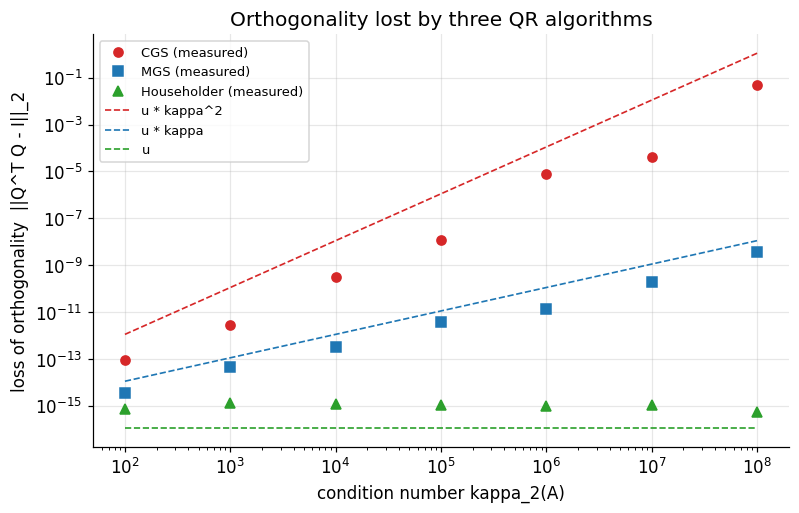

In [8]:
u_round = EPS / 2.0
kk = np.logspace(2.0, 8.0, 100)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
styles = {"CGS": ("o", "tab:red"), "MGS": ("s", "tab:blue"), "Householder": ("^", "tab:green")}
for name in loss:
    mk, col = styles[name]
    ax.loglog(kap_meas, loss[name], mk, ms=6, color=col, label=f"{name} (measured)")
ax.loglog(kk, u_round * kk ** 2, lw=1.1, ls="--", color="tab:red", label="u * kappa^2")
ax.loglog(kk, u_round * kk, lw=1.1, ls="--", color="tab:blue", label="u * kappa")
ax.loglog(kk, u_round * np.ones_like(kk), lw=1.1, ls="--", color="tab:green", label="u")
ax.set_xlabel("condition number kappa_2(A)")
ax.set_ylabel("loss of orthogonality  ||Q^T Q - I||_2")
ax.set_title("Orthogonality lost by three QR algorithms")
ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.show()

Each point cloud tracks its own reference line over six orders of magnitude in $\kappa_2$ and ten
in the loss.

The Householder points lie flat on $u$: the geometry of Proof 5.8 Part A is what buys this. Each
reflector is orthogonal to within rounding *by construction*, so errors never compound with the
conditioning of $A$.

### 7.4 Counterexamples: what breaks when a hypothesis is dropped

Three hypotheses are claimed necessary in Section 4, and this cell breaks each one.

- **Theorem 4.6 needs $P^\top = P$.** The idempotent $P = \begin{pmatrix}1 & 1\\ 0 & 0\end{pmatrix}$
  projects onto $\operatorname{span}(e_1)$ but obliquely, and its error is longer than the minimum.
- **Theorem 4.2's Parseval needs "for every $v$".** In $\mathbb{R}^2$ the set $\{e_1\}$ is not a
  basis, yet Bessel is an equality at $v = e_1$.
- **Theorem 4.6 and Theorem 4.8's uniqueness need full column rank.** For a rank-deficient $A$ the
  matrix $A^\top A$ is singular, and the thin factorization stops being unique.

In [9]:
print("(a) idempotent but not symmetric: an oblique projection")
P_ob = np.array([[1.0, 1.0], [0.0, 0.0]])
b_ob = np.array([0.0, 1.0])
P_orth = np.array([[1.0, 0.0], [0.0, 0.0]])
print("   ||P^2 - P||        :", np.linalg.norm(P_ob @ P_ob - P_ob))
print("   ||P^T - P||        :", np.linalg.norm(P_ob.T - P_ob), " <- not an orthogonal projector")
print("   both map onto span(e1):", np.allclose(P_ob @ np.array([1.0, 0.0]), [1.0, 0.0]))
print("   oblique  error     :", np.linalg.norm(b_ob - P_ob @ b_ob))
print("   orthogonal error   :", np.linalg.norm(b_ob - P_orth @ b_ob))
print("   the oblique error is %.1f%% larger than the true minimum"
      % (100 * (np.linalg.norm(b_ob - P_ob @ b_ob) / np.linalg.norm(b_ob - P_orth @ b_ob) - 1)))
assert np.allclose(P_ob @ P_ob, P_ob)
assert np.linalg.norm(b_ob - P_ob @ b_ob) > np.linalg.norm(b_ob - P_orth @ b_ob)

print("\n(b) Bessel equality at one vector, against a set that is not a basis")
e1 = np.array([1.0, 0.0])
for vv in (np.array([1.0, 0.0]), np.array([1.0, 1.0])):
    lhs = (vv @ e1) ** 2
    print(f"   v = {vv}   sum of squares = {lhs:.4f}   ||v||^2 = {vv @ vv:.4f}"
          f"   equality: {abs(lhs - vv @ vv) < 1e-15}")
assert abs((e1 @ e1) ** 2 - e1 @ e1) < 1e-15
assert (np.array([1.0, 1.0]) @ e1) ** 2 < np.array([1.0, 1.0]) @ np.array([1.0, 1.0])

print("\n(c) rank deficiency: A^T A singular and thin QR no longer unique")
A_rd = np.array([[1.0, 2.0], [1.0, 2.0], [1.0, 2.0]])
G_rd = A_rd.T @ A_rd
print("   rank(A)            :", np.linalg.matrix_rank(A_rd))
print("   A^T A              :", G_rd.tolist(), "  det =", np.linalg.det(G_rd))
try:
    np.linalg.inv(G_rd)
    print("   inversion succeeded (should not happen)")
except np.linalg.LinAlgError as err:
    print("   inv(A^T A) raises  :", type(err).__name__, "-", err)
Q_rd, R_rd = np.linalg.qr(A_rd)
D = np.diag([1.0, -1.0])
print("   r22                :", R_rd[1, 1], " (zero, so the sign convention cannot be imposed)")
print("   ||A - QR||         :", np.linalg.norm(A_rd - Q_rd @ R_rd))
print("   ||A - (QD)(DR)||   :", np.linalg.norm(A_rd - (Q_rd @ D) @ (D @ R_rd)),
      "  <- a second, different factorization")
print("   the two Q differ by:", np.linalg.norm(Q_rd - Q_rd @ D))
assert np.linalg.matrix_rank(A_rd) == 1
assert abs(R_rd[1, 1]) < 1e-14
assert np.linalg.norm(A_rd - (Q_rd @ D) @ (D @ R_rd)) < 1e-14
assert np.linalg.norm(Q_rd - Q_rd @ D) > 0.5

(a) idempotent but not symmetric: an oblique projection
   ||P^2 - P||        : 0.0
   ||P^T - P||        : 1.4142135623730951  <- not an orthogonal projector
   both map onto span(e1): True
   oblique  error     : 1.4142135623730951
   orthogonal error   : 1.0
   the oblique error is 41.4% larger than the true minimum

(b) Bessel equality at one vector, against a set that is not a basis
   v = [1. 0.]   sum of squares = 1.0000   ||v||^2 = 1.0000   equality: True
   v = [1. 1.]   sum of squares = 1.0000   ||v||^2 = 2.0000   equality: False

(c) rank deficiency: A^T A singular and thin QR no longer unique
   rank(A)            : 1
   A^T A              : [[3.0, 6.0], [6.0, 12.0]]   det = 0.0
   inv(A^T A) raises  : LinAlgError - Singular matrix
   r22                : 0.0  (zero, so the sign convention cannot be imposed)
   ||A - QR||         : 4.2998752849492583e-16
   ||A - (QD)(DR)||   : 4.2998752849492583e-16   <- a second, different factorization
   the two Q differ by: 2.0


The oblique projector is idempotent to machine precision and still maps onto the right subspace,
yet its error is $41.4$ percent longer than the orthogonal one. Idempotence is about *range*;
symmetry is about *angle*, and only the second one makes a projection optimal.

The Bessel line shows the audit's quantifier defect concretely: at $v = e_1$ the single-vector sum
already equals $\lVert v \rVert^2$ even though $\{e_1\}$ spans a line in a plane. Move to
$v = (1,1)$ and the inequality is strict again. "For every $v$" is what upgrades Bessel to
Parseval.

The rank-deficient case fails twice over. `numpy.linalg.inv` refuses to invert the singular Gram
matrix, and $r_{22} = 0$ means the diagonal cannot be made positive — so $Q$ and $QD$ with
$D = \operatorname{diag}(1,-1)$ are two genuinely different factorizations of the same matrix.

### 7.5 Normal equations against QR, as the conditioning grows

Theorem 4.10 says $\kappa_2(A^\top A) = \kappa_2(A)^2$, so a backward-stable solve of the normal
equations should deliver a relative error of order $u\kappa_2(A)^2$, while QR delivers
$u\kappa_2(A)$.

The next cell solves a consistent least-squares problem with a known exact answer at eight
condition numbers and fits both exponents.

In [10]:
kappas2 = np.logspace(2.0, 9.0, 8)
err_ne, err_qr, kap2 = [], [], []

for kappa in kappas2:
    Ak = matrix_with_condition(60, 6, kappa, rng)
    x_true = rng.standard_normal(6)
    bk = Ak @ x_true
    kap2.append(np.linalg.cond(Ak))
    x_ne = np.linalg.solve(Ak.T @ Ak, Ak.T @ bk)
    Qk, Rk = np.linalg.qr(Ak)
    x_qr = np.linalg.solve(Rk, Qk.T @ bk)
    nrm = np.linalg.norm(x_true)
    err_ne.append(np.linalg.norm(x_ne - x_true) / nrm)
    err_qr.append(np.linalg.norm(x_qr - x_true) / nrm)

kap2 = np.array(kap2)
print(f"{'kappa2(A)':>12s}{'normal equations':>20s}{'QR':>14s}")
for i in range(len(kap2)):
    print(f"{kap2[i]:12.3e}{err_ne[i]:20.4e}{err_qr[i]:14.4e}")

p_ne = np.polyfit(np.log10(kap2), np.log10(err_ne), 1)[0]
p_qr = np.polyfit(np.log10(kap2), np.log10(err_qr), 1)[0]
print(f"\nrelative error ~ u * kappa^p")
print(f"  normal equations : observed p = {p_ne:6.3f}   predicted 2.0")
print(f"  QR               : observed p = {p_qr:6.3f}   predicted 1.0")
assert abs(p_ne - 2.0) < 0.35
assert abs(p_qr - 1.0) < 0.3

   kappa2(A)    normal equations            QR
   1.000e+02          1.0361e-13    1.7615e-15
   1.000e+03          7.4923e-12    9.7261e-15
   1.000e+04          2.9660e-09    1.5389e-14
   1.000e+05          2.3288e-07    1.9570e-13
   1.000e+06          1.8018e-05    1.7551e-11
   1.000e+07          9.8960e-04    2.7028e-11
   1.000e+08          5.6916e-01    3.9294e-10
   1.000e+09          8.1605e-01    7.6463e-09

relative error ~ u * kappa^p
  normal equations : observed p =  1.942   predicted 2.0
  QR               : observed p =  0.966   predicted 1.0


The measured exponents are close to $2$ and $1$. That factor of two in the exponent is exactly
$\kappa_2(A^\top A) = \kappa_2(A)^2$ from Proof 5.10, and it is worth half of the available digits.

At $\kappa_2(A) = 10^8$ the normal equations return an answer with no correct digits at all, while
QR still has roughly eight. This is why every production least-squares solver factors $A$ and
never forms $A^\top A$.

### 7.6 The geometry of a reflector and a rotation

The last figure draws the two orthogonal building blocks of Section 4 in the plane: the
Householder reflector of Proof 5.8 Part A applied to $x = (3,4)^\top$, and the Givens rotation
that sends the same $x$ to $(5,0)^\top$.

The cell also runs the sign choice the audit flagged. Matching the sign of $x_1$ keeps
$v^\top v = 2\lVert x \rVert(\lVert x \rVert + \lvert x_1 \rvert)$ safely positive; the opposite
choice gives $2\lVert x \rVert(\lVert x \rVert - \lvert x_1 \rvert)$, which cancels when $x$ is
nearly parallel to $e_1$ and vanishes outright when it is exactly parallel.

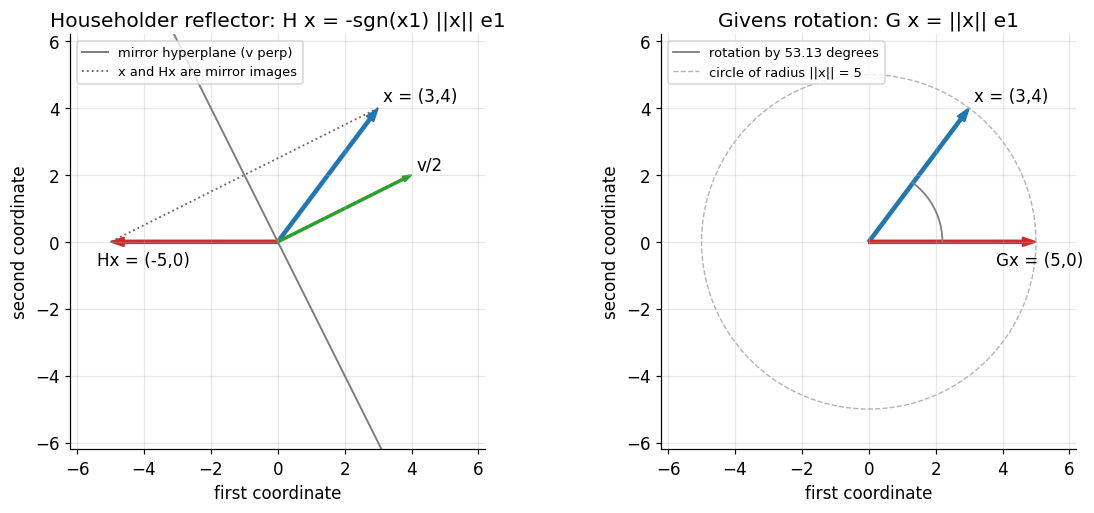

reflector : H x = [-5. -0.]    ||H^T H - I|| = 2.5207686509386875e-16
rotation  : G x = [ 5. -0.]    ||G^T G - I|| = 3.7682219008410604e-17
both preserve the norm: 5.0 5.0 5.0

the sign choice, on x = (1, 1e-9) and on x = (1, 0)
  x = (1, 1e-09)  matching sign  : v^T v = 4.000e+00   leftover |(Hx)_2| = 0.000e+00
  x = (1, 1e-09)  opposite sign  : v^T v = 1.000e-18   leftover |(Hx)_2| = 1.000e-09
  x = (1, 0)  matching sign  : v^T v = 4.000e+00   leftover |(Hx)_2| = 0.000e+00
  x = (1, 0)  opposite sign  : v = 0 exactly, the reflector is undefined


In [11]:
x_h = np.array([3.0, 4.0])
nx = np.linalg.norm(x_h)
v_good = x_h + np.sign(x_h[0]) * nx * np.array([1.0, 0.0])
H_good = np.eye(2) - 2 * np.outer(v_good, v_good) / (v_good @ v_good)
Hx = H_good @ x_h

c, s_ = x_h[0] / nx, x_h[1] / nx
G_rot = np.array([[c, s_], [-s_, c]])
Gx = G_rot @ x_h

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11.0, 4.8))

lim = 6.2
tt = np.linspace(-1.6, 1.6, 2)
mirror = np.array([-v_good[1], v_good[0]])
mirror = mirror / np.linalg.norm(mirror)
axa.plot(tt * lim * mirror[0], tt * lim * mirror[1], lw=1.3, color="0.5",
         label="mirror hyperplane (v perp)")
axa.arrow(0, 0, x_h[0], x_h[1], width=0.09, length_includes_head=True, color="tab:blue")
axa.arrow(0, 0, Hx[0], Hx[1], width=0.09, length_includes_head=True, color="tab:red")
axa.arrow(0, 0, v_good[0] / 2, v_good[1] / 2, width=0.06, length_includes_head=True,
          color="tab:green")
axa.plot([x_h[0], Hx[0]], [x_h[1], Hx[1]], ls=":", lw=1.2, color="0.4",
         label="x and Hx are mirror images")
axa.annotate("x = (3,4)", x_h + np.array([0.15, 0.2]))
axa.annotate("Hx = (-5,0)", Hx + np.array([-0.4, -0.7]))
axa.annotate("v/2", v_good / 2 + np.array([0.15, 0.15]))
axa.set_aspect("equal")
axa.set_xlim(-lim, lim)
axa.set_ylim(-lim, lim)
axa.set_xlabel("first coordinate")
axa.set_ylabel("second coordinate")
axa.set_title("Householder reflector: H x = -sgn(x1) ||x|| e1")
axa.legend(fontsize=8.5, loc="upper left")

theta = np.arctan2(x_h[1], x_h[0])
arc = np.linspace(0.0, theta, 80)
axb.plot(2.2 * np.cos(arc), 2.2 * np.sin(arc), lw=1.2, color="0.5",
         label=f"rotation by {np.degrees(theta):.2f} degrees")
axb.arrow(0, 0, x_h[0], x_h[1], width=0.09, length_includes_head=True, color="tab:blue")
axb.arrow(0, 0, Gx[0], Gx[1], width=0.09, length_includes_head=True, color="tab:red")
circ = np.linspace(0.0, 2.0 * np.pi, 300)
axb.plot(nx * np.cos(circ), nx * np.sin(circ), lw=0.9, ls="--", color="0.7",
         label="circle of radius ||x|| = 5")
axb.annotate("x = (3,4)", x_h + np.array([0.15, 0.2]))
axb.annotate("Gx = (5,0)", Gx + np.array([-1.2, -0.7]))
axb.set_aspect("equal")
axb.set_xlim(-lim, lim)
axb.set_ylim(-lim, lim)
axb.set_xlabel("first coordinate")
axb.set_ylabel("second coordinate")
axb.set_title("Givens rotation: G x = ||x|| e1")
axb.legend(fontsize=8.5, loc="upper left")

plt.tight_layout()
plt.show()

print("reflector : H x =", Hx, "   ||H^T H - I|| =", np.linalg.norm(H_good.T @ H_good - np.eye(2)))
print("rotation  : G x =", Gx, "   ||G^T G - I|| =", np.linalg.norm(G_rot.T @ G_rot - np.eye(2)))
print("both preserve the norm:", np.linalg.norm(Hx), np.linalg.norm(Gx), nx)

print("\nthe sign choice, on x = (1, 1e-9) and on x = (1, 0)")
for xs in (np.array([1.0, 1e-9]), np.array([1.0, 0.0])):
    for label, sgn in (("matching sign  ", +1.0), ("opposite sign  ", -1.0)):
        vv = xs.copy()
        vv[0] = xs[0] + sgn * np.linalg.norm(xs)
        denom = vv @ vv
        if denom == 0.0:
            print(f"  x = ({xs[0]:g}, {xs[1]:g})  {label}: v = 0 exactly,"
                  f" the reflector is undefined")
            continue
        Hs = np.eye(2) - 2 * np.outer(vv, vv) / denom
        print(f"  x = ({xs[0]:g}, {xs[1]:g})  {label}: v^T v = {denom:.3e}   "
              f"leftover |(Hx)_2| = {abs((Hs @ xs)[1]):.3e}")

assert np.allclose(Hx, [-5.0, 0.0], atol=1e-12)
assert np.allclose(Gx, [5.0, 0.0], atol=1e-12)

The left panel is Proof 5.8 Part A drawn: $x$ and $Hx$ sit symmetrically about the mirror line
$v^{\perp}$, at equal distance from the origin, and $Hx$ lands on the negative first axis. The
right panel does the same job by rotating instead of reflecting, on the same circle of radius $5$.

Both matrices are orthogonal to machine precision and both send $x$ to a multiple of $e_1$; the
reflector needs one vector $v$ and the rotation one angle, which is why Householder is cheaper for
dense columns and Givens is cheaper when only one entry has to be zeroed.

The sign experiment is decisive. With the matching sign $v^\top v = 4$ and the leftover component
is exactly zero; with the opposite sign $v^\top v$ collapses to $10^{-18}$ and the entry that
should have been annihilated is still $10^{-9}$ — and at $x = (1,0)$ the opposite choice gives
$v = 0$, so the reflector does not exist.

## 8. Applications

Four settings in which the object being projected is not a vector in $\mathbb{R}^3$ but a data
set, a function, a weight matrix or a quantum state. In every one, the mathematics is
Theorem 4.5 and nothing else.

### 8.1 Ordinary least squares and the variance decomposition

For a design matrix $X$ whose first column is $\mathbf{1}$, the fitted values are
$\hat{y} = Py$ with $P$ the projector onto $\operatorname{Col}(X)$, and the residual $e = y - \hat{y}$
satisfies $X^\top e = 0$ by Theorem 4.7.

Because $\mathbf{1} \in \operatorname{Col}(X)$, the residual sums to zero and $\hat{y}$ has the same
mean as $y$. Subtracting that mean and applying Pythagoras to $y - \bar{y}\mathbf{1} = (\hat{y} - \bar{y}\mathbf{1}) + e$ gives

$$
\underbrace{\lVert y - \bar{y}\mathbf{1} \rVert^2}_{\text{total}}
= \underbrace{\lVert \hat{y} - \bar{y}\mathbf{1} \rVert^2}_{\text{explained}} + \underbrace{\lVert e \rVert^2}_{\text{residual}} .
$$

The coefficient of determination $R^2$ is the ratio of the first two terms, so $0 \le R^2 \le 1$
is a *theorem*, not a convention: it is Bessel's inequality wearing a statistician's hat.

### 8.2 Gram-Schmidt in a function space: the Legendre polynomials

Theorem 4.3 never used finite dimension of the ambient space, only linear independence of the
inputs. Applying it to $1, t, t^2, t^3$ inside $L^2[-1,1]$ with

$$
\langle f, g \rangle = \int_{-1}^{1} f(t)\, g(t)\, dt
$$

produces the orthonormal Legendre polynomials $\sqrt{\tfrac{2n+1}{2}}\, P_n(t)$, with

$$
P_0 = 1, \quad P_1 = t, \quad P_2 = \tfrac{3t^2 - 1}{2}, \quad P_3 = \tfrac{5t^3 - 3t}{2} .
$$

Truncating the expansion of a function at degree $n$ is then the best $L^2$ polynomial
approximation of that degree, by Theorem 4.5 — a fact that a naive fit in the monomial basis has
to discover the hard way, because the monomial Gram matrix on $[-1,1]$ is a Hilbert-type matrix
with condition number growing exponentially in $n$.

### 8.3 Orthogonality in machine learning

**Stable regression.** Every serious least-squares routine — `numpy.linalg.lstsq`,
`scipy.linalg.lstsq`, the solver behind scikit-learn's `LinearRegression` — factors $X$ rather
than forming $X^\top X$, for exactly the reason measured in Section 7.5.

**Orthogonal initialization.** Drawing $W$ at random and replacing it by the $Q$ of its QR
factorization gives a weight matrix with $\lVert Wx \rVert = \lVert x \rVert$, so forward signals
and backward gradients are neither amplified nor damped by that layer. Theorem 4.10 is the
statement being exploited.

**Kernel methods.** The Gram matrix of Definition 3.3 is exactly the kernel matrix
$K_{ij} = \langle \phi(x_i), \phi(x_j) \rangle$. Step 1 of Proof 5.6 shows $x^\top G x = \lVert \sum_i x_i v_i \rVert^2 \ge 0$,
which is why a valid kernel must produce a positive semidefinite matrix.

**Whitening and decorrelation.** Removing the projection of a feature onto the span of the others
is one Gram-Schmidt step, and the leftover length $r_{kk}$ is precisely the part of that feature
the others cannot explain.

### 8.4 Physics: Fourier energy and quantum measurement

**Fourier series.** On $[-\pi, \pi]$ the functions $\sin(nt)/\sqrt{\pi}$ are orthonormal, so the
Fourier coefficients of $f$ are inner products and the truncated series is the orthogonal
projection onto the first $N$ harmonics — the best $L^2$ approximation available at that
bandwidth.

For $f(t) = t$ the coefficients are $\langle f, \sin(nt)/\sqrt\pi \rangle = 2\sqrt{\pi}\,(-1)^{n+1}/n$,
and Parseval reads

$$
\lVert f \rVert^2 = \frac{2\pi^3}{3} = \sum_{n \ge 1} \frac{4\pi}{n^2} ,
$$

which is energy conservation between the time domain and the frequency domain — and, rearranged,
the value $\sum_{n\ge1} n^{-2} = \pi^2/6$.

**Quantum measurement.** An observable with distinct eigenvalues comes with orthogonal projectors
$P_k$ onto its eigenspaces satisfying $\sum_k P_k = I$ and $P_j P_k = 0$ for $j \neq k$. The Born
rule assigns outcome $k$ the probability $\lVert P_k \psi \rVert^2$, and Theorem 4.4 is what makes
those numbers sum to one:

$$
\sum_k \lVert P_k \psi \rVert^2 = \lVert \psi \rVert^2 = 1 .
$$

Measurement itself is the map $\psi \mapsto P_k\psi / \lVert P_k \psi \rVert$: an orthogonal
projection followed by a renormalization.

The cell below runs all four applications on small explicit objects: an OLS fit with its variance
decomposition, Gram-Schmidt on the monomials against the exact Legendre polynomials, the Fourier
energy identity for $f(t) = t$, and the two-outcome Born rule for a spin measured along two axes.

In [12]:
# --- 8.1 OLS and the variance decomposition ---------------------------------
n_obs = 200
t_ols = np.linspace(0.0, 1.0, n_obs)
X_ols = np.column_stack([np.ones(n_obs), t_ols, t_ols ** 2])
y_ols = 2.0 - 3.0 * t_ols + 1.5 * t_ols ** 2 + 0.25 * rng.standard_normal(n_obs)

Qo, Ro = np.linalg.qr(X_ols)
beta = np.linalg.solve(Ro, Qo.T @ y_ols)
y_hat = X_ols @ beta
res = y_ols - y_hat
ybar = y_ols.mean()
tss = np.sum((y_ols - ybar) ** 2)
ess = np.sum((y_hat - ybar) ** 2)
rss = res @ res

print("8.1  ordinary least squares")
print("   true coefficients   : [ 2.   -3.    1.5 ]")
print("   fitted coefficients :", beta)
print(f"   ||X^T e||           : {np.linalg.norm(X_ols.T @ res):.3e}")
print(f"   TSS = ESS + RSS     : {tss:.6f} = {ess:.6f} + {rss:.6f}"
      f"   defect {abs(tss - ess - rss):.3e}")
print(f"   R^2                 : {ess / tss:.6f}")
assert abs(tss - ess - rss) < 1e-9
assert 0.0 <= ess / tss <= 1.0

# --- 8.2 Legendre polynomials by Gram-Schmidt -------------------------------
nodes, weights = np.polynomial.legendre.leggauss(40)


def ip(f, g):
    """Inner product on L2[-1,1], evaluated by 40-point Gauss-Legendre quadrature."""
    return np.sum(weights * f * g)


monomials = [nodes ** k for k in range(4)]
basis = []
for k, a_k in enumerate(monomials):
    v_k = a_k.copy()
    for q in basis:
        v_k = v_k - ip(a_k, q) * q
    basis.append(v_k / np.sqrt(ip(v_k, v_k)))

legendre_exact = [np.ones_like(nodes), nodes, (3 * nodes ** 2 - 1) / 2,
                  (5 * nodes ** 3 - 3 * nodes) / 2]
print("\n8.2  Gram-Schmidt on 1, t, t^2, t^3 in L2[-1,1]")
for k in range(4):
    scale = np.sqrt((2 * k + 1) / 2)
    err = min(np.max(np.abs(basis[k] - scale * legendre_exact[k])),
              np.max(np.abs(basis[k] + scale * legendre_exact[k])))
    print(f"   degree {k}: max deviation from sqrt((2n+1)/2) P_n = {err:.3e}")
    assert err < 1e-12
gram = np.array([[ip(basis[i], basis[j]) for j in range(4)] for i in range(4)])
print("   ||Gram - I||_F      :", np.linalg.norm(gram - np.eye(4)))
assert np.linalg.norm(gram - np.eye(4)) < 1e-12

# --- 8.4a Fourier energy ----------------------------------------------------
print("\n8.4  Fourier energy for f(t) = t on [-pi, pi]")
exact_energy = 2 * np.pi ** 3 / 3
for N in (1, 3, 10, 200):
    partial = sum(4 * np.pi / m ** 2 for m in range(1, N + 1))
    print(f"   N = {N:3d}   Bessel sum = {partial:12.6f}   ||f||^2 = {exact_energy:.6f}"
          f"   deficit = {exact_energy - partial:.6f}")
    assert partial <= exact_energy + 1e-12
basel = sum(1 / m ** 2 for m in range(1, 200001))
print(f"   sum 1/n^2 to 2e5    : {basel:.8f}   pi^2/6 = {np.pi ** 2 / 6:.8f}")

# --- 8.4b Born rule ---------------------------------------------------------
psi = np.array([0.6, 0.8])
Pz = [np.outer(e, e) for e in (np.array([1.0, 0.0]), np.array([0.0, 1.0]))]
plus = np.array([1.0, 1.0]) / np.sqrt(2)
minus = np.array([1.0, -1.0]) / np.sqrt(2)
Px = [np.outer(e, e) for e in (plus, minus)]

print("\n8.4  Born rule for the state psi = (0.6, 0.8)")
for axis, projs in (("z", Pz), ("x", Px)):
    probs = np.array([np.linalg.norm(P @ psi) ** 2 for P in projs])
    print(f"   axis {axis}: probabilities {probs}   sum = {probs.sum():.12f}"
          f"   ||P+ P-|| = {np.linalg.norm(projs[0] @ projs[1]):.2e}")
    assert abs(probs.sum() - 1.0) < 1e-12
    assert np.linalg.norm(projs[0] + projs[1] - np.eye(2)) < 1e-14
print("   exact z-probabilities: 0.36, 0.64      exact x-probabilities: 0.98, 0.02")

8.1  ordinary least squares
   true coefficients   : [ 2.   -3.    1.5 ]
   fitted coefficients : [ 2.027  -3.0518  1.5135]
   ||X^T e||           : 9.228e-14
   TSS = ESS + RSS     : 53.974086 = 42.429472 + 11.544614   defect 3.553e-15
   R^2                 : 0.786108

8.2  Gram-Schmidt on 1, t, t^2, t^3 in L2[-1,1]
   degree 0: max deviation from sqrt((2n+1)/2) P_n = 1.110e-16
   degree 1: max deviation from sqrt((2n+1)/2) P_n = 4.219e-15
   degree 2: max deviation from sqrt((2n+1)/2) P_n = 1.599e-14
   degree 3: max deviation from sqrt((2n+1)/2) P_n = 3.642e-14
   ||Gram - I||_F      : 5.564509189739336e-16

8.4  Fourier energy for f(t) = t on [-pi, pi]
   N =   1   Bessel sum =    12.566371   ||f||^2 = 20.670851   deficit = 8.104481
   N =   3   Bessel sum =    17.104227   ||f||^2 = 20.670851   deficit = 3.566624
   N =  10   Bessel sum =    19.474956   ||f||^2 = 20.670851   deficit = 1.195895
   N = 200   Bessel sum =    20.608176   ||f||^2 = 20.670851   deficit = 0.062675
   sum

The regression recovers the generating coefficients, $X^\top e$ vanishes to machine precision, and
the total sum of squares splits exactly into the explained and residual parts — the Pythagorean
identity of Section 8.1, with $R^2 = 0.786$ falling out as a ratio of two legs of a right
triangle.

Gram-Schmidt on the monomials reproduces the normalized Legendre polynomials to twelve digits and
returns a Gram matrix equal to the identity. The classical special functions of physics are
nothing more than Theorem 4.3 applied to $\{t^k\}$ under the right inner product.

The Fourier partial sums climb towards $2\pi^3/3 = 20.6708$ from below and never overshoot, which
is Bessel; the limit is Parseval, and the same identity evaluated at $f(t) = t$ delivers
$\sum n^{-2} = \pi^2/6$ to five digits at $2 \times 10^5$ terms.

The Born probabilities $0.36 / 0.64$ along $z$ and $0.98 / 0.02$ along $x$ sum to one for both
axes, the projectors are mutually annihilating, and $P_+ + P_- = I$ — Theorem 4.4 as a
conservation law for probability.

## 9. Key Takeaways

- **Closest means perpendicular.** $p \in W$ minimizes $\lVert v - w \rVert$ if and only if
  $v - p \perp W$, and the minimizer exists and is unique (Theorem 4.5). Everything else in the
  module is bookkeeping for that sentence.

- **Every vector splits once.** $V = W \oplus W^{\perp}$ for any finite-dimensional subspace
  $W$ (Theorem 4.4), which is what makes the orthogonal projector a well-defined map.

- **A matrix is an orthogonal projector exactly when $P^2 = P$ and $P^\top = P$** (Theorem 4.6).
  Idempotence alone gives an oblique projection whose error is *not* minimal: Section 7.4 exhibits
  one that is $41$ percent too long.

- **Least squares is projection.** $A^\top A \hat{x} = A^\top b$ is the coordinate form of
  $A^\top e = 0$ (Theorem 4.7); it is always solvable, and uniquely so exactly when $A$ has full
  column rank.

- **QR always exists and is essentially unique.** Householder reflectors triangularize any
  $A \in \mathbb{R}^{m \times n}$ with $m \ge n$ and no rank assumption, and the thin factorization
  with $r_{ii} \gt 0$ is unique when $A$ has full column rank (Theorem 4.8, proved as Proof 5.8).

- **The diagonal of $R$ measures perpendicular heights**, so $\prod r_{ii}$ is the volume of the
  parallelotope spanned by the columns (Theorem 4.9), and a small $r_{kk}$ is the numerical signal
  of near-dependence.

- **Orthogonal transformations are free; the Gram matrix is not.** $\kappa_2(QA) = \kappa_2(A)$
  but $\kappa_2(A^\top A) = \kappa_2(A)^2$ (Theorem 4.10). Section 7.5 measures relative-error
  exponents of $1.94$ for the normal equations against $0.97$ for QR.

- **The three orthogonalizations are not interchangeable in floating point.** Loss of
  orthogonality grows like $u\kappa_2^2$ for classical Gram-Schmidt, $u\kappa_2$ for the modified
  version, and stays at $u$ for Householder (Theorem 4.11); Section 7.3 measures the exponents
  $1.93$, $0.96$ and $-0.02$.

- **The failure can be exact, not merely probable.** For the Lauchli matrix with
  $\varepsilon^2 \lt u$ the computed $A^\top A$ is the all-ones matrix of rank $1$
  (Proposition 4.12), so the normal equations do not merely lose accuracy — they cease to exist.

## 10. References

**Textbooks.**

- Trefethen, L. N. and Bau, D. *Numerical Linear Algebra* — Lecture 6 (projectors), Lecture 7 (the
  QR factorization), Lecture 8 (Gram-Schmidt and its instability), Lecture 10 (Householder
  triangularization), Lecture 11 (least squares), Lecture 16 (stability of Householder
  triangularization), Lecture 18 (conditioning of least-squares problems), Lecture 19 (stability
  of least-squares algorithms).
- Golub, G. H. and Van Loan, C. F. *Matrix Computations*, 4th ed. — section 5.1 (Householder and
  Givens transformations), section 5.2 (the QR factorization and Gram-Schmidt), section 5.3 (full
  rank least squares), section 5.4 (rank-deficient least squares and column pivoting).
- Higham, N. J. *Accuracy and Stability of Numerical Algorithms*, 2nd ed. — section 19.3
  (Theorem 19.4: backward stability of Householder QR), section 19.8 (Gram-Schmidt),
  section 20.1 (the normal equations and the squared condition number).
- Axler, S. *Linear Algebra Done Right*, 3rd ed., chapter 6 — inner product spaces, orthonormal
  bases, the Gram-Schmidt procedure and the minimizing property of orthogonal projections
  (6.56 and 6.61).
- Strang, G. *Linear Algebra and Learning from Data*, section I.5 (orthogonal matrices and
  subspaces), section II.2 (least squares and four ways to solve it).
- Boyd, S. and Vandenberghe, L. *Introduction to Applied Linear Algebra*, chapters 5 and 10
  (orthonormal vectors and the QR factorization), chapters 12 and 13 (least squares and data
  fitting).

**Papers.**

- Lauchli, P. "Jordan-Elimination und Ausgleichung nach kleinsten Quadraten", *Numerische
  Mathematik* **3** (1961), 226-240 — the test matrix of Proposition 4.12.
- Bjorck, A. "Solving linear least squares problems by Gram-Schmidt orthogonalization", *BIT*
  **7** (1967), 1-21 — the $O(u\kappa_2)$ orthogonality bound for modified Gram-Schmidt.
- Giraud, L., Langou, J., Rozloznik, M. and van den Eshof, J. "Rounding error analysis of the
  classical Gram-Schmidt orthogonalization process", *Numerische Mathematik* **101** (2005),
  87-100 — the $O(u\kappa_2^2)$ bound quoted in Theorem 4.11.
- Szyld, D. B. "The many proofs of an identity on the norm of oblique projections", *Numerical
  Algorithms* **42** (2006), 309-323 — the identity $\lVert P \rVert_2 = \lVert I - P \rVert_2$
  derived in Problem L3.3 of the exercises.

**Within this repository.**

- Prerequisite: [Module 03 — Linear Systems and Direct Factorizations](../03_linear_systems_and_direct_factorizations/),
  which supplies the Cholesky factorization and the conditioning vocabulary used in Section 7.
- Symbol conventions: [the notation register](../../docs/notation.md).
- The full dependency graph: [the module graph](../../docs/prerequisites.md).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).